# Lab session 1

**Vanessa Gómez Verdejo,  Pablo Martínez Olmos, Alejandro Lancho Serrano, Emilio Parrado Hernández**

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~emipar/BBVA/INTRO/img/logo_uc3m_foot.jpg' width=400 />


# Age Prediction from Face Images with PyTorch

Welcome to this hands-on lab! In this notebook, you will build and train deep learning models using PyTorch to solve a regression task: predicting a person’s age from facial images using the UTKFace dataset.

We’ll guide you through the process of building simple and advanced models, using modern deep learning practices, and integrating tools like PyTorch Lightning and MLflow to streamline development and monitor results.

**General Objective**: Familiarize yourself with PyTorch by constructing and training models for a regression task (age prediction from facial images), using simple architectures (MLP and CNN), data augmentation, and transfer learning.

## 1. Dataset Setup

We will use the **UTKFace dataset**, a large collection of face images labeled with age (and other attributes).

The original UTKFace dataset can be downloaded from [Kaggle](https://www.kaggle.com/datasets/moritzm00/utkface-cropped?resource=download). However, to simplify preprocessing and reduce loading times, we provide two preprocessed versions of the dataset in the form of PyTorch tensors:

* The image tensors are stored in the file `full_UTK_64x64.pt`  containing all images at resolution 64x64.  To simplify and accelerate your experimentation.
* The corresponding age labels are provided in `full_ages_UTK.pt`, which align one-to-one with the image tensors.

The data is stored as preprocessed PyTorch tensors in `.pt` files. You won’t have to deal with raw image loading. Instead, your first task is to implement a custom PyTorch `Dataset` and prepare the corresponding **DataLoaders** for training, validation, and testing.

This class has to:
- Load preprocessed tensors.
- Scale pixel values to the [0, 1] range.
- Randomly split the dataset into **50% training**, **25% validation**, and **25% test**.
- Return images and corresponding ages as `float32`.

Once you instantiate the dataset, make sure to build the corresponding PyTorch **DataLoaders**, with appropriate batch sizes (e.g., 32 or 64) and shuffling for the training set.

Next, it's important to explore and visualize the dataset to gain some intuition about the task. Start by displaying a few sample images along with their corresponding ages to get a sense of the data quality and variability. Then, plot the distribution of ages across the dataset to understand whether it is balanced or skewed toward certain age ranges.


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt

In [2]:
#2 Implementar un Dataset custom
class UTKFaceDataset(Dataset):
    """
    Dataset custom para UTKFace usando archivos .pt ya preprocesados.

    Cada elemento del dataset devuelve:
        image: tensor de imagen en float32
        age: tensor con la edad en float32
    """

    def __init__(self, images_path, ages_path):
        # Cargamos las imágenes y las edades desde archivos .pt
        self.images = torch.load(images_path)
        self.ages = torch.load(ages_path)

        # Convertimos las imágenes a float32
        self.images = self.images.to(torch.float32)

        # Si las imágenes vienen en rango [0, 255], las escalamos a [0, 1]
        # Si ya vienen normalizadas, no hacemos nada
        if self.images.max() > 1:
            self.images = self.images / 255.0

        # Convertimos las edades a float32
        self.ages = self.ages.to(torch.float32)

        # Para regresión suele ser cómodo que las etiquetas tengan forma [N, 1]
        # en lugar de [N]
        if self.ages.ndim == 1:
            self.ages = self.ages.view(-1, 1)

    def __getitem__(self, index):
        # Recuperamos una imagen y su edad correspondiente
        image = self.images[index]
        age = self.ages[index]

        return image, age

    def __len__(self):
        # Devolvemos la cantidad total de muestras
        return self.ages.shape[0]

In [3]:
"""
Instanciar el Dataset
- Usar rutas para leer los archivos compartidos.
- Verificar que imágenes y edades estén alineadas.
"""

'\nInstanciar el Dataset\nParte del pedido cubierta:\n- Usar rutas para leer los archivos compartidos.\n- Verificar que imágenes y edades estén alineadas.\n'

In [4]:
# Rutas a los archivos .pt
images_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_UTK_64x64.pt"
ages_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_ages_UTK.pt"

# Creamos el dataset completo
utk_dataset = UTKFaceDataset(images_path, ages_path)

# Chequeos básicos
print("Cantidad total de muestras:", len(utk_dataset))
print("Forma de una imagen:", utk_dataset[0][0].shape)
print("Forma de una edad:", utk_dataset[0][1].shape)
print("Tipo de dato de las imágenes:", utk_dataset[0][0].dtype)
print("Tipo de dato de las edades:", utk_dataset[0][1].dtype)
print("Valor mínimo de píxel:", utk_dataset.images.min().item())
print("Valor máximo de píxel:", utk_dataset.images.max().item())

Cantidad total de muestras: 23705
Forma de una imagen: torch.Size([3, 64, 64])
Forma de una edad: torch.Size([1])
Tipo de dato de las imágenes: torch.float32
Tipo de dato de las edades: torch.float32
Valor mínimo de píxel: 0.0
Valor máximo de píxel: 1.0


In [5]:
"""
4. Split aleatorio 50/25/25
- Separar aleatoriamente el dataset en:
  - 50% training
  - 25% validation
  - 25% test
"""

# Tamaño total del dataset
dataset_size = len(utk_dataset)

# Calculamos los tamaños pedidos
train_size = int(0.50 * dataset_size)
val_size = int(0.25 * dataset_size)

# El test recibe el resto para evitar perder muestras por redondeo
test_size = dataset_size - train_size - val_size

# Hacemos el split aleatorio.
# Usamos manual_seed(42) para que el resultado sea reproducible.
train_dataset, val_dataset, test_dataset = random_split(
    utk_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Muestras de entrenamiento:", len(train_dataset))
print("Muestras de validación:", len(val_dataset))
print("Muestras de test:", len(test_dataset))

Muestras de entrenamiento: 11852
Muestras de validación: 5926
Muestras de test: 5927


In [6]:
"""
5. Crear DataLoaders
- Crear DataLoaders para training, validation y test.
- Usar batch size apropiado.
- Activar shuffle=True solo en entrenamiento.
"""
batch_size = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [7]:
"""
6. Verificar un batch
- Confirmar que los DataLoaders devuelven imágenes y edades en float32.
- Confirmar formas de entrada y salida.
"""
# Tomamos un batch del DataLoader de entrenamiento
images, ages = next(iter(train_loader))

print("Forma del batch de imágenes:", images.shape)
print("Forma del batch de edades:", ages.shape)
print("Tipo de dato de imágenes:", images.dtype)
print("Tipo de dato de edades:", ages.dtype)
print("Valor mínimo del batch:", images.min().item())
print("Valor máximo del batch:", images.max().item())

Forma del batch de imágenes: torch.Size([64, 3, 64, 64])
Forma del batch de edades: torch.Size([64, 1])
Tipo de dato de imágenes: torch.float32
Tipo de dato de edades: torch.float32
Valor mínimo del batch: 0.0
Valor máximo del batch: 1.0


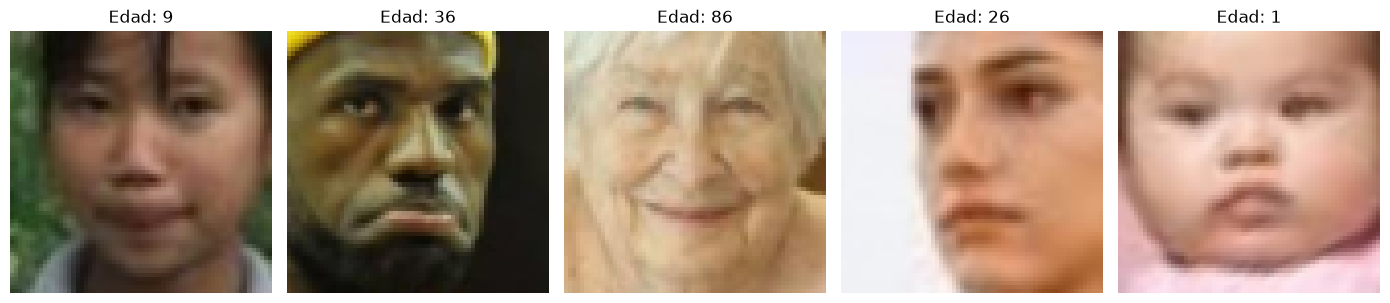

In [8]:
"""
7. Mostrar imágenes con sus edades
- Visualizar algunas imágenes.
- Mostrar la edad asociada a cada imagen.
- Ganar intuición sobre calidad y variabilidad del dataset.
"""

def show_samples(dataset, num_images=5):
    plt.figure(figsize=(14, 4))

    for i in range(num_images):
        image, age = dataset[i]

        image = image.detach().cpu()
        age = age.item()

        if image.ndim == 3 and image.shape[0] in [1, 3]:
            image = image.permute(1, 2, 0)

        if image.ndim == 3 and image.shape[-1] == 1:
            image = image.squeeze(-1)

        # Convertimos a lista de Python primero y luego a NumPy
        image_np = np.array(image.tolist())

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image_np, cmap="gray")
        plt.title(f"Edad: {age:.0f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
show_samples(utk_dataset, num_images=5)

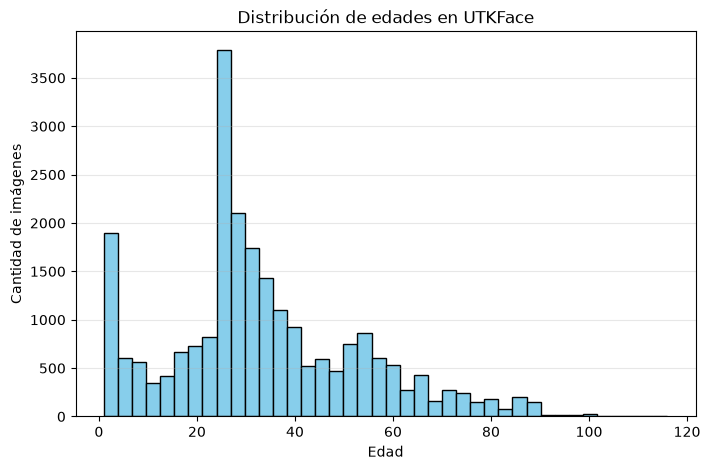

=== Estadísticas de Edad ===
Edad mínima : 1 años
Edad máxima : 116 años
Edad media  : 33.30 años
Edad mediana: 29.00 años


In [9]:
"""8. Plotear distribución de edades
- Analizar si las edades están balanceadas.
- Detectar si el dataset está sesgado hacia ciertos rangos de edad.
"""
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_age_distribution(dataset):
    """
    Grafica la distribución de edades del dataset completo de forma segura.
    Funciona eficientemente incluso si el dataset de imágenes es muy pesado.
    """
    # 1. Extraemos únicamente la propiedad de las edades
    # Acceder a las etiquetas no carga las imágenes pesadas en memoria RAM.
    ages_data = dataset.ages

    # 2. Conversión segura a NumPy
    # Si 'ages_data' es un Tensor de PyTorch, usamos .tolist()
    if isinstance(ages_data, torch.Tensor):
        ages = np.array(ages_data.detach().cpu().tolist()).flatten()
    else:
        # Si ya era una lista, un array de NumPy o una Serie de Pandas
        ages = np.asarray(ages_data).flatten()

    # 3. Creación del histograma para visualizar la distribución
    plt.figure(figsize=(8, 5))
    
    # Dibujamos las barras con borde negro para mayor claridad gráfica
    plt.hist(ages, bins=40, color="skyblue", edgecolor="black")
    
    # Etiquetas de ejes y títulos
    plt.xlabel("Edad")
    plt.ylabel("Cantidad de imágenes")
    plt.title("Distribución de edades en UTKFace")
    
    # Cuadrícula horizontal tenue para facilitar la lectura visual
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    # 4. Cálculo e impresión de métricas descriptivas básicas
    print("=== Estadísticas de Edad ===")
    print(f"Edad mínima : {ages.min():.0f} años")
    print(f"Edad máxima : {ages.max():.0f} años")
    print(f"Edad media  : {ages.mean():.2f} años")
    print(f"Edad mediana: {np.median(ages):.2f} años")
plot_age_distribution(utk_dataset)

## 2. Building a Simple MLP

With the data ready, your next task is to design a **Multilayer Perceptron (MLP)**. The architecture will serve as a baseline for later models. Here is the basic structure:

- Input: Flattened image tensor (e.g., for 64×64 images → 3 × 64 × 64 = 12288 input units)
- Hidden layer: 128 neurons, followed by a **ReLU** activation
- Output layer: A single neuron predicting a continuous value (the age)

Use `nn.MSELoss` as your training loss, and also compute the validation MSE (Mean Square Error) during during the training.

Wrap this model inside a `LightningModule`, and use the `LightningTrainer` to handle training loops. Don’t forget to implement:
- `training_step`, `validation_step`, and optionally `test_step`
- Optimizer configuration (e.g., Adam with learning rate 1e-3)

Train the model for **50 epochs** and log all key metrics using **MLflow**; for example, you can log training/validation loss. You can structure your logging using the built-in logger from PyTorch Lightning.

Later,  and plot some example predictions vs. ground truth.


After training, visualize and interpret your results:
- Analyze the training and validation loss curves.
- Compute training and test MSE and MAE (Mean Absolute Error) for interpretability
- Compare predicted vs. actual ages on a few test samples.
- Analyze how the model performs across different age ranges (e.g., is it worse for children or elderly faces?).


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

# Lightning puede estar instalado con dos nombres distintos según la versión.
try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

from pytorch_lightning.loggers import MLFlowLogger

import mlflow
from pathlib import Path


C:\Users\felix\.conda\envs\fraud-conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
"""2.2 Definir el MLP base
- Entrada: imagen aplanada.
- Capa oculta: 128 neuronas.
- Activación: ReLU.
- Salida: 1 neurona para predecir edad continua.
    """
class PyTorchAgeMLP(nn.Module):
    """
    MLP simple para predicción de edad.

    Arquitectura:
    - Entrada: imagen aplanada
    - Capa oculta: 128 neuronas + ReLU
    - Salida: 1 neurona, que representa la edad predicha
    """

    def __init__(self, input_dim=3*64*64):
        super().__init__()

        self.all_layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # Aplanamos la imagen desde [B, C, H, W] a [B, C*H*W]
        x = torch.flatten(x, start_dim=1)

        # Calculamos la edad predicha
        age_pred = self.all_layers(x)

        return age_pred

In [12]:
"""2.3 Chequear la dimensión de entrada
- Verificar si las imágenes tienen forma compatible con 3 x 64 x 64 = 12288.
- Adaptar automáticamente el input_dim.
"""
# Tomamos un batch para inspeccionar la forma de las imágenes
images_batch, ages_batch = next(iter(train_loader))

print("Forma del batch de imágenes:", images_batch.shape)
print("Forma del batch de edades:", ages_batch.shape)

# Calculamos la dimensión de entrada a partir de los datos reales
input_dim = images_batch[0].numel()

print("Dimensión de entrada para el MLP:", input_dim)


Forma del batch de imágenes: torch.Size([64, 3, 64, 64])
Forma del batch de edades: torch.Size([64, 1])
Dimensión de entrada para el MLP: 12288


In [13]:
"""2.4 Envolver el modelo en LightningModule
- Usar nn.MSELoss.
- Implementar training_step.
- Implementar validation_step.
- Implementar test_step.
- Configurar optimizador Adam con lr=1e-3.
- Loggear métricas principales."""
class LitAgeMLP(pl.LightningModule):
    """
    LightningModule para entrenar el MLP de predicción de edad.

    Este módulo organiza:
    - forward pass
    - training_step
    - validation_step
    - test_step
    - configuración del optimizador
    """

    def __init__(self, model, learning_rate=1e-3):
        super().__init__()

        # Guardamos hiperparámetros para que Lightning/MLflow los puedan registrar
        self.save_hyperparameters(ignore=["model"])

        self.model = model
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        """
        Paso común para train/validation/test.

        Recibe un batch:
            images: imágenes
            ages: edades reales

        Devuelve:
            loss: MSE
            preds: edades predichas
            ages: edades reales
        """

        images, ages = batch

        # Aseguramos que las edades sean float32 y tengan forma [B, 1]
        ages = ages.float()
        if ages.ndim == 1:
            ages = ages.view(-1, 1)

        preds = self(images)

        loss = self.loss_fn(preds, ages)

        return loss, preds, ages

    def training_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        # Log de la pérdida de entrenamiento
        self.log(
            "train_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        # Log de la pérdida de validación
        self.log(
            "val_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def test_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        # Log de la pérdida de test
        self.log(
            "test_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def configure_optimizers(self):
        # Optimizador Adam pedido en el enunciado
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.learning_rate
        )

        return optimizer


In [14]:
"""2.5 Configurar MLflow
- Loggear métricas con MLflow.
- Usar el logger integrado de PyTorch Lightning.
# Carpeta local donde se guardarán los experimentos de MLflow"""
TRACKING_URI = "sqlite:///mlruns/mlflow.db"
EXPERIMENT = "UTKFace_Age_Regression"

# Creamos la carpeta mlruns si no existe
Path("mlruns").mkdir(exist_ok=True)

# Configuramos MLflow
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT)

# Logger de MLflow para Lightning
mlf_logger = MLFlowLogger(
    experiment_name=EXPERIMENT,
    tracking_uri=TRACKING_URI,
    run_name="MLP_128_MSE_lr1e-3"
)


2026/09/16 15:22:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/16 15:22:11 INFO mlflow.store.db.utils: Updating database tables
2026/09/16 15:22:13 INFO mlflow.tracking.fluent: Experiment with name 'UTKFace_Age_Regression' does not exist. Creating a new experiment.


In [16]:
"""2.6 Instanciar y entrenar el modelo por 50 epochs
- Crear el MLP.
- Entrenar con Trainer.
- Usar 50 epochs.
- Loggear train/validation loss."""
# Creamos el modelo base
age_mlp = PyTorchAgeMLP(input_dim=input_dim)

# Lo envolvemos en Lightning
lit_age_mlp = LitAgeMLP(
    model=age_mlp,
    learning_rate=1e-3
)

# Trainer de Lightning
trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices="auto",
    deterministic=True,
    log_every_n_steps=10,
    logger=mlf_logger
)

# Entrenamiento
trainer.fit(
    lit_age_mlp,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name    | Type          | Params | Mode  | FLOPs
----------------------------------------------------------
0 | model   | PyTorchAgeMLP | 1.6 M  | train | 0    
1 | loss_fn | MSELoss       | 0      | train | 0    
----------------------------------------------------------
1.6 M     Trainable params
0         Non-trainable params
1.6 M     Total params
6.292     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode
0         Total Flo

C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 186/186 [00:03<00:00, 48.56it/s, v_num=b5e6]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 186/186 [00:04<00:00, 45.69it/s, v_num=b5e6, val_loss=350.0, train_loss=441.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 186/186 [00:03<00:00, 47.72it/s, v_num=b5e6, val_loss=279.0, train_loss=311.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 186/186 [00:03<00:00, 48.75it/s, v_num=b5e6, val_loss=260.0, train_loss=274.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 186/186 [00:03<00:00, 47.40it/s, v_num=b5e6, val_loss=254.0, train_loss=255.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 186/186 [00:04<00:00, 4

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 186/186 [00:04<00:00, 38.47it/s, v_num=b5e6, val_loss=172.0, train_loss=147.0]


In [17]:
"""2.7 Evaluar en test
Parte del pedido cubierta:
- Usar test_step.
- Obtener MSE en test."""
test_results = trainer.test(
    lit_age_mlp,
    dataloaders=test_loader
)

test_results

C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 93/93 [00:00<00:00, 146.66it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss            172.3970947265625
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 172.3970947265625}]

In [20]:
"""2.8 Función para calcular MSE y MAE
- Calcular MSE para training y test.
- Calcular MAE para interpretabilidad.
- Guardar predicciones para análisis posterior."""

def evaluate_regression_model(model, dataloader, device=None):
    """
    Evalúa un modelo de regresión calculando:
    - MSE: Mean Squared Error
    - MAE: Mean Absolute Error

    También devuelve las predicciones y valores reales.
    """

    if device is None:
        device = next(model.parameters()).device

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, ages in dataloader:
            images = images.to(device)
            ages = ages.to(device).float()

            if ages.ndim == 1:
                ages = ages.view(-1, 1)

            preds = model(images)

            all_preds.append(preds.detach().cpu())
            all_targets.append(ages.detach().cpu())

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    mse = F.mse_loss(all_preds, all_targets).item()
    mae = F.l1_loss(all_preds, all_targets).item()

    return {
        "mse": mse,
        "mae": mae,
        "preds": all_preds.numpy().flatten(),
        "targets": all_targets.numpy().flatten()
    }
train_metrics = evaluate_regression_model(lit_age_mlp, train_loader)
test_metrics = evaluate_regression_model(lit_age_mlp, test_loader)
val_metrics = evaluate_regression_model(lit_age_mlp, val_loader)

print("Train MSE:", train_metrics["mse"])
print("Train MAE:", train_metrics["mae"])

print("Test MSE:", test_metrics["mse"])
print("Test MAE:", test_metrics["mae"])

print("Val MSE:", val_metrics["mse"])
print("Val MAE:", val_metrics["mae"])


Train MSE: 138.7816619873047
Train MAE: 8.597414016723633
Test MSE: 172.39706420898438
Test MAE: 9.486212730407715
Val MSE: 171.9920196533203
Val MAE: 9.411632537841797


In [19]:
"""2.9 Loggear métricas finales en MLflow
Parte del pedido cubierta:
- Registrar MSE y MAE finales.
- Guardar métricas interpretables en el experimento."""
# Registramos métricas finales en el mismo run de MLflow
mlf_logger.experiment.log_metric(mlf_logger.run_id, "train_mse_final", train_metrics["mse"])
mlf_logger.experiment.log_metric(mlf_logger.run_id, "train_mae_final", train_metrics["mae"])
mlf_logger.experiment.log_metric(mlf_logger.run_id, "test_mse_final", test_metrics["mse"])
mlf_logger.experiment.log_metric(mlf_logger.run_id, "test_mae_final", test_metrics["mae"])

In [21]:
mlf_logger.experiment.log_metric(mlf_logger.run_id, "val_mse_final", val_metrics["mse"])
mlf_logger.experiment.log_metric(mlf_logger.run_id, "val_mae_final", val_metrics["mae"])

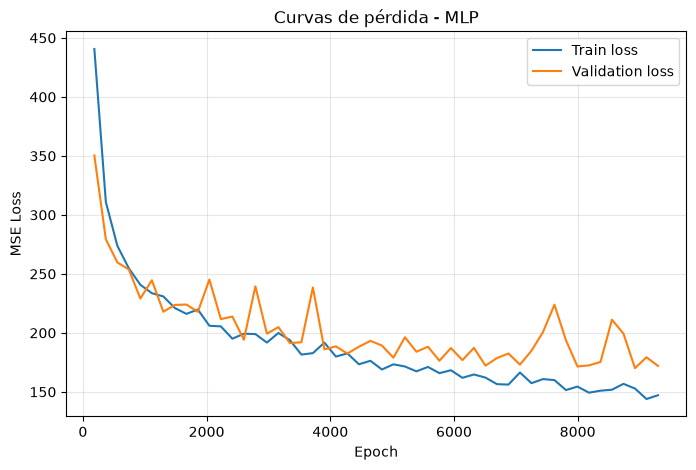

In [22]:
"""2.10 Graficar curvas de train/validation loss
- Analizar curvas de entrenamiento y validación.
- Interpretar si hay underfitting u overfitting."""
import pandas as pd
from mlflow.tracking import MlflowClient

def plot_loss_curves_from_mlflow(run_id, tracking_uri=TRACKING_URI):
    """
    Recupera desde MLflow las curvas de loss de entrenamiento y validación.
    """

    client = MlflowClient(tracking_uri=tracking_uri)

    train_history = client.get_metric_history(run_id, "train_loss")
    val_history = client.get_metric_history(run_id, "val_loss")

    train_epochs = [m.step for m in train_history]
    train_losses = [m.value for m in train_history]

    val_epochs = [m.step for m in val_history]
    val_losses = [m.value for m in val_history]

    plt.figure(figsize=(8, 5))
    plt.plot(train_epochs, train_losses, label="Train loss")
    plt.plot(val_epochs, val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Curvas de pérdida - MLP")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
plot_loss_curves_from_mlflow(mlf_logger.run_id)

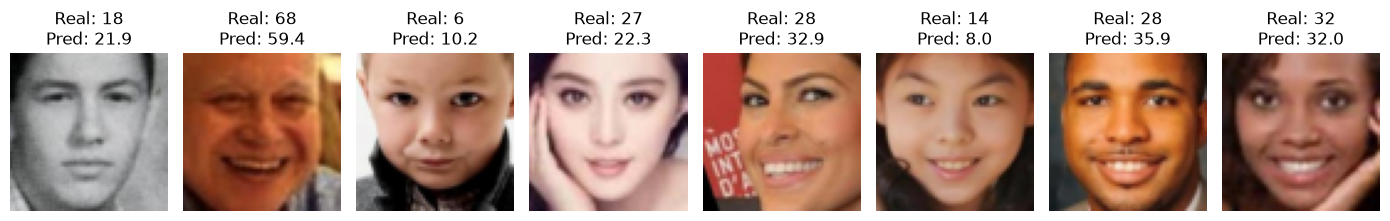

In [23]:
"""2.11 Predicciones vs valores reales en ejemplos de test
- Comparar edad predicha vs edad real.
- Mostrar algunos ejemplos visuales."""
def show_predictions(model, dataloader, num_images=8, device=None):
    """
    Muestra imágenes del conjunto de test junto con:
    - edad real
    - edad predicha por el modelo
    """

    if device is None:
        device = next(model.parameters()).device

    model.eval()

    images, ages = next(iter(dataloader))

    images = images.to(device)
    ages = ages.float()

    if ages.ndim == 1:
        ages = ages.view(-1, 1)

    with torch.no_grad():
        preds = model(images).detach().cpu()

    images = images.detach().cpu()
    ages = ages.detach().cpu()

    plt.figure(figsize=(14, 4))

    for i in range(num_images):
        image = images[i]
        true_age = ages[i].item()
        pred_age = preds[i].item()

        # Convertimos de [C, H, W] a [H, W, C] si corresponde
        if image.ndim == 3 and image.shape[0] in [1, 3]:
            image = image.permute(1, 2, 0)

        # Si es grayscale, eliminamos el canal
        if image.ndim == 3 and image.shape[-1] == 1:
            image = image.squeeze(-1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"Real: {true_age:.0f}\nPred: {pred_age:.1f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
show_predictions(lit_age_mlp, test_loader, num_images=8)

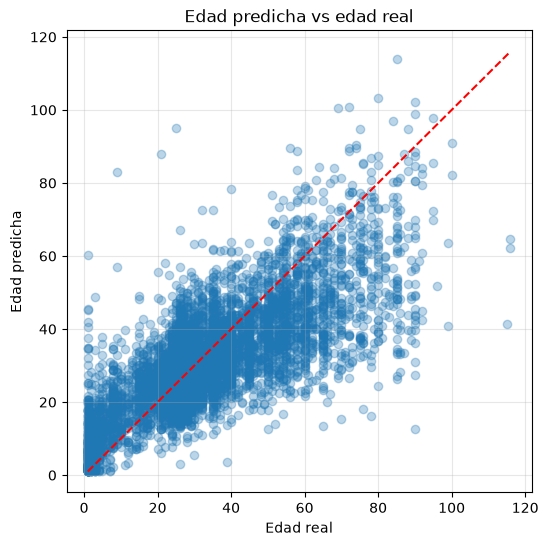

In [24]:
"""2.12 Predicted vs actual ages
- Visualizar globalmente la relación entre edades reales y predichas.
- Ver si el modelo subestima o sobreestima edades."""
def plot_predicted_vs_actual(metrics):
    """
    Grafica edad real vs edad predicha.
    Si el modelo fuera perfecto, los puntos caerían sobre la diagonal.
    """

    targets = metrics["targets"]
    preds = metrics["preds"]

    plt.figure(figsize=(6, 6))
    plt.scatter(targets, preds, alpha=0.3)

    min_age = min(targets.min(), preds.min())
    max_age = max(targets.max(), preds.max())

    plt.plot([min_age, max_age], [min_age, max_age], color="red", linestyle="--")
    plt.xlabel("Edad real")
    plt.ylabel("Edad predicha")
    plt.title("Edad predicha vs edad real")
    plt.grid(alpha=0.3)
    plt.show()
plot_predicted_vs_actual(test_metrics)


Niños: MAE = 8.20 años | muestras = 839
Adolescentes: MAE = 8.02 años | muestras = 298
Adultos jóvenes: MAE = 6.45 años | muestras = 2981
Adultos: MAE = 11.17 años | muestras = 1096
Adultos mayores: MAE = 21.71 años | muestras = 713


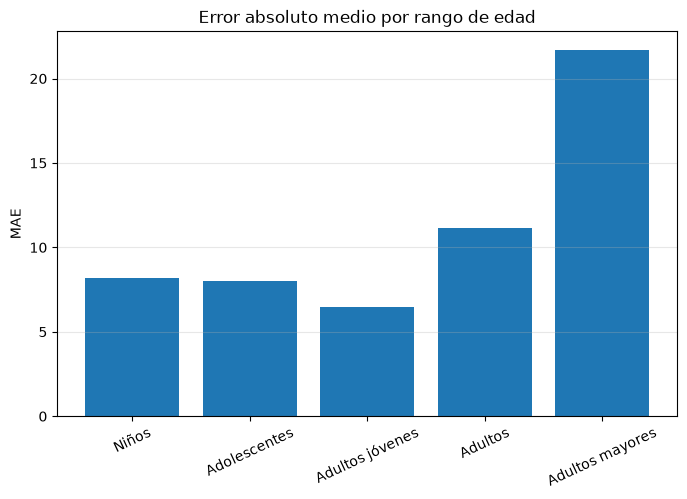

In [25]:
"""2.13 Analizar desempeño por rangos de edad
- Ver si el modelo funciona peor en niños, adultos o adultos mayores.
- Calcular MAE por rango etario."""
def analyze_error_by_age_range(metrics):
    """
    Calcula el MAE por rangos de edad para interpretar
    en qué grupos el modelo comete más error.
    """

    targets = metrics["targets"]
    preds = metrics["preds"]

    age_bins = [
        (0, 12, "Niños"),
        (13, 19, "Adolescentes"),
        (20, 39, "Adultos jóvenes"),
        (40, 59, "Adultos"),
        (60, 120, "Adultos mayores")
    ]

    range_names = []
    range_mae = []
    range_counts = []

    for min_age, max_age, name in age_bins:
        mask = (targets >= min_age) & (targets <= max_age)

        if mask.sum() > 0:
            mae = np.mean(np.abs(preds[mask] - targets[mask]))

            range_names.append(name)
            range_mae.append(mae)
            range_counts.append(mask.sum())

            print(f"{name}: MAE = {mae:.2f} años | muestras = {mask.sum()}")
        else:
            print(f"{name}: no hay muestras en este rango")

    plt.figure(figsize=(8, 5))
    plt.bar(range_names, range_mae)
    plt.ylabel("MAE")
    plt.title("Error absoluto medio por rango de edad")
    plt.xticks(rotation=25)
    plt.grid(axis="y", alpha=0.3)
    plt.show()
analyze_error_by_age_range(test_metrics)

In [ ]:
"""
2.14 Interpretación esperada
El MLP funciona como modelo baseline para la predicción de edad. 

-loss de entrenamiento se alejan entre si a medida que crece los epocs, 
ademas de una clara diferencia entre Train MSE: 138.7816619873047 y 
Test MSE: 172.39706420898438 ,lo que indica overfitting.

El MAE: 9.486212730407715, en promedio, el modelo se equivoca aproximadamente 9.5 años en test.

El análisis por rangos de edad permite ver que el modelo rinde mejor en adultos jovenes, igual en adolecentes
y niños, y en los segmentos en que peor lo hace es en adultos y adultos mayores.

"""

## 3. Convolutional Neural Networks (CNNs) for Age Prediction

In this part, you’ll move beyond fully connected layers and explore the power of **Convolutional Neural Networks (CNNs)** for image-based regression. CNNs are particularly well-suited to visual data, as they can exploit spatial hierarchies and local patterns more effectively than MLPs.

Your goal is to implement a simple CNN-based regressor and evaluate whether it outperforms the MLP from Part 2.

Thus, you will implement a CNN with the following structure:
- Two convolutional layers with 3×3 kernels and ReLU activation.
- 2×2 max pooling after each convolution to reduce spatial dimensions.
- A fully connected layer with 128 neurons.
- A final output layer predicting a single real value (age).

As before, implement the model using **PyTorch Lightning**, wrapping the architecture into a `LightningModule`. Train the model using the same loss function (`MSELoss`).

Once training is complete, perform a thorough evaluation of the CNN:
- Plot training and validation losses over time using **MLflow**. Note that you can now compare this run directly against your MLP results. Did it converge faster?
- Compute train and test MSE and MAE. Did the CNN achieve lower MAE or MSE than the MLP? Does it generalize better to unseen data?
- Compare again predicted vs. actual ages on a few test samples and analyze how the model performs across different age ranges.



In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

from pytorch_lightning.loggers import MLFlowLogger
from mlflow.tracking import MlflowClient

import mlflow

"""3.2 Definir la CNN regresora
- Dos capas convolucionales con kernels 3x3.
- Activación ReLU.
- MaxPool2d de 2x2 después de cada convolución.
- Capa fully connected con 128 neuronas.
- Capa final con 1 salida para predecir edad."""

class PyTorchAgeCNN(nn.Module):
    """
    CNN simple para predicción de edad.

    Arquitectura:
    - Conv2d + ReLU + MaxPool2d
    - Conv2d + ReLU + MaxPool2d
    - Flatten
    - Linear 128 + ReLU
    - Linear 1

    La salida es un único valor continuo: la edad predicha.
    """

    def __init__(self, input_channels=3, num_outputs=1):
        super().__init__()

        self.conv_layers = nn.Sequential(
            # Entrada esperada: [B, C, 64, 64]
            nn.Conv2d(
                in_channels=input_channels,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # [B, 32, 32, 32]

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)   # [B, 64, 16, 16]
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_outputs)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        age_pred = self.fc_layers(x)

        return age_pred


In [28]:
"""3.3 Verificar canales de entrada
- Confirmar si las imágenes tienen 1 o 3 canales.
- Crear la CNN compatible con los datos reales."""
# Tomamos un batch para revisar la forma de las imágenes
images_batch, ages_batch = next(iter(train_loader))

print("Forma del batch de imágenes:", images_batch.shape)
print("Forma del batch de edades:", ages_batch.shape)
input_channels = images_batch.shape[1]

print("Cantidad de canales de entrada:", input_channels)


Forma del batch de imágenes: torch.Size([64, 3, 64, 64])
Forma del batch de edades: torch.Size([64, 1])
Cantidad de canales de entrada: 3


In [29]:
"""3.4 Envolver la CNN en LightningModule
- Implementar training_step.
- Implementar validation_step.
- Implementar test_step.
- Usar MSELoss.
- Configurar optimizador Adam con lr=1e-3."""
class LitAgeCNN(pl.LightningModule):
    """
    LightningModule para entrenar una CNN regresora de edad.

    Organiza:
    - forward
    - training_step
    - validation_step
    - test_step
    - configure_optimizers
    """

    def __init__(self, model, learning_rate=1e-3):
        super().__init__()

        # Guardamos hiperparámetros para logging
        self.save_hyperparameters(ignore=["model"])

        self.model = model
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        """
        Paso común para entrenamiento, validación y test.
        """

        images, ages = batch

        # Aseguramos tipo float32 y forma [B, 1]
        ages = ages.float()
        if ages.ndim == 1:
            ages = ages.view(-1, 1)

        preds = self(images)

        loss = self.loss_fn(preds, ages)

        return loss, preds, ages

    def training_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "train_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "val_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def test_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "test_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.learning_rate
        )

        return optimizer
"""3.5 Configurar MLflow para la corrida CNN
- Loggear métricas con MLflow.
- Crear una corrida diferente a la del MLP.
- Permitir comparación directa MLP vs CNN dentro del mismo experimento."""
# Usamos el mismo experimento que en la Parte 2 para poder comparar MLP vs CNN
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT)

cnn_logger = MLFlowLogger(
    experiment_name=EXPERIMENT,
    tracking_uri=TRACKING_URI,
    run_name="CNN_2Conv_128_MSE_lr1e-3"
)


In [30]:
"""3.6 Instanciar y entrenar la CNN
- Entrenar el modelo CNN.
- Usar la misma función de pérdida que el MLP.
- Guardar train/validation loss.
- Permitir comparar si converge más rápido que el MLP.
# Creamos la arquitectura CNN"""
age_cnn = PyTorchAgeCNN(
    input_channels=input_channels,
    num_outputs=1
)

# La envolvemos en Lightning
lit_age_cnn = LitAgeCNN(
    model=age_cnn,
    learning_rate=1e-3
)

# Trainer de Lightning
cnn_trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices="auto",
    deterministic=True,
    log_every_n_steps=10,
    logger=cnn_logger
)

# Entrenamiento
cnn_trainer.fit(
    lit_age_cnn,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)
"""3.7 Evaluar CNN en test
- Ejecutar test_step.
- Obtener loss en test."""
cnn_test_results = cnn_trainer.test(
    lit_age_cnn,
    dataloaders=test_loader
)


"""3.8 Calcular MSE y MAE
- Calcular train MSE.
- Calcular train MAE.
- Calcular test MSE.
- Calcular test MAE.
- Evaluar si la CNN mejora respecto al MLP."""
def evaluate_regression_model(model, dataloader, device=None):
    """
    Evalúa un modelo de regresión.

    Calcula:
    - MSE: error cuadrático medio
    - MAE: error absoluto medio

    También devuelve:
    - predicciones
    - valores reales
    """

    if device is None:
        device = next(model.parameters()).device

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, ages in dataloader:
            images = images.to(device)
            ages = ages.to(device).float()

            if ages.ndim == 1:
                ages = ages.view(-1, 1)

            preds = model(images)

            all_preds.append(preds.detach().cpu())
            all_targets.append(ages.detach().cpu())

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    mse = F.mse_loss(all_preds, all_targets).item()
    mae = F.l1_loss(all_preds, all_targets).item()

    return {
        "mse": mse,
        "mae": mae,
        "preds": all_preds.numpy().flatten(),
        "targets": all_targets.numpy().flatten()
    }
cnn_train_metrics = evaluate_regression_model(lit_age_cnn, train_loader)
cnn_test_metrics = evaluate_regression_model(lit_age_cnn, test_loader)

print("CNN Train MSE:", cnn_train_metrics["mse"])
print("CNN Train MAE:", cnn_train_metrics["mae"])

print("CNN Test MSE:", cnn_test_metrics["mse"])
print("CNN Test MAE:", cnn_test_metrics["mae"])
"""3.9 Loggear métricas finales en MLflow
Parte del pedido cubierta:
- Guardar métricas finales interpretables.
- Poder comparar MSE/MAE entre MLP y CNN."""
cnn_logger.experiment.log_metric(cnn_logger.run_id, "train_mse_final", cnn_train_metrics["mse"])
cnn_logger.experiment.log_metric(cnn_logger.run_id, "train_mae_final", cnn_train_metrics["mae"])
cnn_logger.experiment.log_metric(cnn_logger.run_id, "test_mse_final", cnn_test_metrics["mse"])
cnn_logger.experiment.log_metric(cnn_logger.run_id, "test_mae_final", cnn_test_metrics["mae"])


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name    | Type          | Params | Mode  | FLOPs
----------------------------------------------------------
0 | model   | PyTorchAgeCNN | 2.1 M  | train | 0    
1 | loss_fn | MSELoss       | 0      | train | 0    
----------------------------------------------------------
2.1 M     Trainable params
0         Non-trainable params
2.1 M     Total params
8.467     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode
0         Total Flo

Epoch 0: 100%|██████████| 186/186 [00:32<00:00,  5.76it/s, v_num=998d]     
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 186/186 [00:30<00:00,  6.03it/s, v_num=998d, val_loss=324.0, train_loss=418.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 186/186 [00:30<00:00,  6.07it/s, v_num=998d, val_loss=211.0, train_loss=265.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 186/186 [00:30<00:00,  6.04it/s, v_num=998d, val_loss=203.0, train_loss=209.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 186/186 [00:31<00:00,  5.94it/s, v_num=998d, val_loss=179.0, train_loss=187.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 186/186 [00:31<00:

`Trainer.fit` stopped: `max_epochs=50` reached.


Testing DataLoader 0: 100%|██████████| 93/93 [00:08<00:00, 10.97it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss            118.791748046875
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
CNN Train MSE: 7.759366035461426
CNN Train MAE: 2.101848840713501
CNN Test MSE: 118.79175567626953
CNN Test MAE: 7.751900672912598


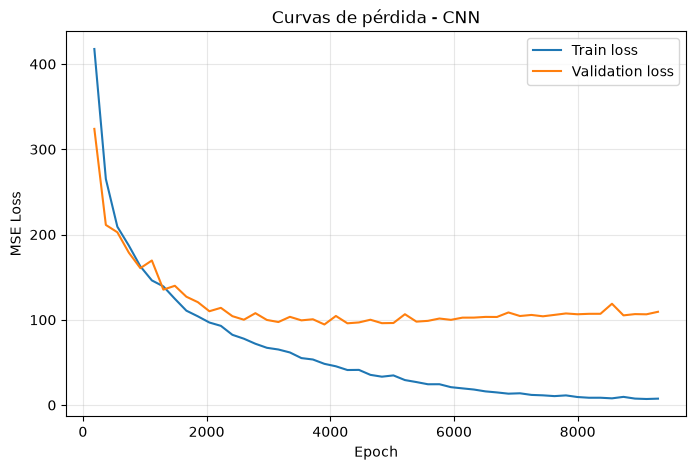

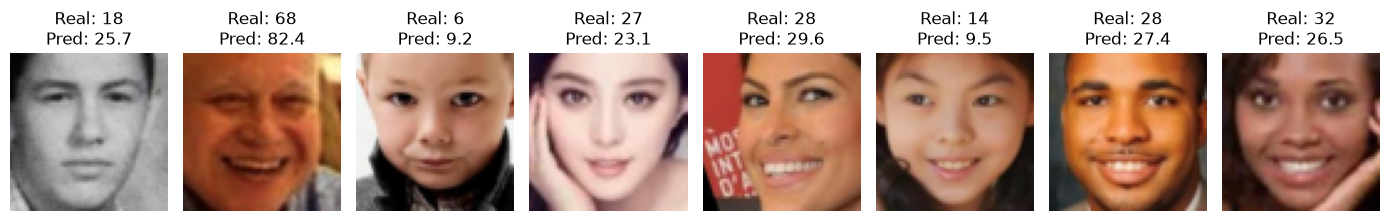

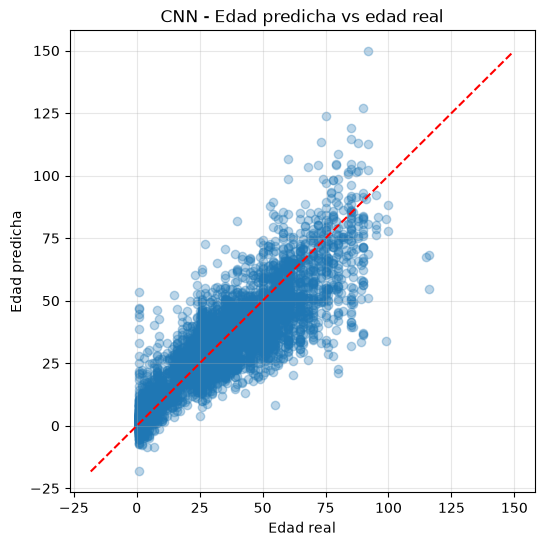

Niños: MAE = 5.17 años | muestras = 839
Adolescentes: MAE = 6.24 años | muestras = 298
Adultos jóvenes: MAE = 5.67 años | muestras = 2981
Adultos: MAE = 10.48 años | muestras = 1096
Adultos mayores: MAE = 15.93 años | muestras = 713


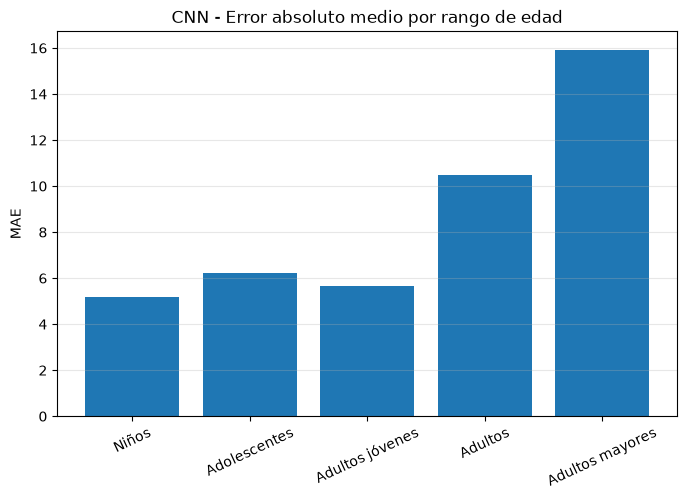

In [31]:
"""3.10 Graficar pérdidas de entrenamiento y validación
- Graficar train loss.
- Graficar validation loss.
- Analizar convergencia de la CNN.
- Comparar luego contra el MLP."""
def plot_loss_curves_from_mlflow(run_id, tracking_uri=TRACKING_URI):
    """
    Recupera desde MLflow las curvas de train_loss y val_loss
    para un run específico.
    """

    client = MlflowClient(tracking_uri=tracking_uri)

    train_history = client.get_metric_history(run_id, "train_loss")
    val_history = client.get_metric_history(run_id, "val_loss")

    train_steps = [m.step for m in train_history]
    train_losses = [m.value for m in train_history]

    val_steps = [m.step for m in val_history]
    val_losses = [m.value for m in val_history]

    plt.figure(figsize=(8, 5))
    plt.plot(train_steps, train_losses, label="Train loss")
    plt.plot(val_steps, val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Curvas de pérdida - CNN")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
plot_loss_curves_from_mlflow(cnn_logger.run_id)

"""3.11 Comparar CNN vs MLP desde MLflow
- Comparar CNN contra MLP.
- Ver si la CNN obtiene menor MSE o MAE.
- Ver si generaliza mejor."""

def show_experiment_runs(experiment_name=EXPERIMENT, tracking_uri=TRACKING_URI):
    """
    Muestra una tabla con las corridas registradas en MLflow.
    Sirve para comparar MLP vs CNN usando métricas finales.
    """

    mlflow.set_tracking_uri(tracking_uri)

    experiment = mlflow.get_experiment_by_name(experiment_name)

    if experiment is None:
        print("No existe el experimento:", experiment_name)
        return None

    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=["metrics.test_mae_final ASC"]
    )

    cols_to_show = [
        "tags.mlflow.runName",
        "metrics.train_mse_final",
        "metrics.train_mae_final",
        "metrics.test_mse_final",
        "metrics.test_mae_final",
        "params.learning_rate"
    ]

    available_cols = [col for col in cols_to_show if col in runs.columns]

    return runs[available_cols]
show_experiment_runs()
"""
3.12 Mostrar predicciones vs edades reales
Parte del pedido cubierta:
- Comparar edad predicha vs edad real en muestras de test.
- Visualizar cualitativamente los errores de la CNN.
"""
def show_predictions(model, dataloader, num_images=8, device=None):
    """
    Muestra imágenes del conjunto de test con:
    - edad real
    - edad predicha por el modelo
    """

    if device is None:
        device = next(model.parameters()).device

    model.eval()

    images, ages = next(iter(dataloader))

    images = images.to(device)
    ages = ages.float()

    if ages.ndim == 1:
        ages = ages.view(-1, 1)

    with torch.no_grad():
        preds = model(images).detach().cpu()

    images = images.detach().cpu()
    ages = ages.detach().cpu()

    plt.figure(figsize=(14, 4))

    for i in range(num_images):
        image = images[i]
        true_age = ages[i].item()
        pred_age = preds[i].item()

        if image.ndim == 3 and image.shape[0] in [1, 3]:
            image = image.permute(1, 2, 0)

        if image.ndim == 3 and image.shape[-1] == 1:
            image = image.squeeze(-1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"Real: {true_age:.0f}\nPred: {pred_age:.1f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
show_predictions(lit_age_cnn, test_loader, num_images=8)
"""3.13 Gráfico predicted vs actual
- Ver globalmente si las predicciones siguen la diagonal ideal.
- Detectar si el modelo subestima o sobreestima edades."""
def plot_predicted_vs_actual(metrics, title="Edad predicha vs edad real"):
    """
    Grafica edad real contra edad predicha.
    La línea roja representa predicción perfecta.
    """

    targets = metrics["targets"]
    preds = metrics["preds"]

    plt.figure(figsize=(6, 6))
    plt.scatter(targets, preds, alpha=0.3)

    min_age = min(targets.min(), preds.min())
    max_age = max(targets.max(), preds.max())

    plt.plot([min_age, max_age], [min_age, max_age], color="red", linestyle="--")
    plt.xlabel("Edad real")
    plt.ylabel("Edad predicha")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()
plot_predicted_vs_actual(
    cnn_test_metrics,
    title="CNN - Edad predicha vs edad real"
)
"""3.14 Analizar error por rangos de edad
- Evaluar si la CNN funciona peor en niños, adultos o adultos mayores.
- Interpretar diferencias de desempeño por rango etario."""
def analyze_error_by_age_range(metrics):
    """
    Calcula el MAE por rangos de edad.

    Esto permite ver si el modelo se equivoca más en ciertos grupos,
    por ejemplo niños o adultos mayores.
    """

    targets = metrics["targets"]
    preds = metrics["preds"]

    age_bins = [
        (0, 12, "Niños"),
        (13, 19, "Adolescentes"),
        (20, 39, "Adultos jóvenes"),
        (40, 59, "Adultos"),
        (60, 120, "Adultos mayores")
    ]

    range_names = []
    range_mae = []

    for min_age, max_age, name in age_bins:
        mask = (targets >= min_age) & (targets <= max_age)

        if mask.sum() > 0:
            mae = np.mean(np.abs(preds[mask] - targets[mask]))

            range_names.append(name)
            range_mae.append(mae)

            print(f"{name}: MAE = {mae:.2f} años | muestras = {mask.sum()}")
        else:
            print(f"{name}: no hay muestras en este rango")

    plt.figure(figsize=(8, 5))
    plt.bar(range_names, range_mae)
    plt.ylabel("MAE")
    plt.title("CNN - Error absoluto medio por rango de edad")
    plt.xticks(rotation=25)
    plt.grid(axis="y", alpha=0.3)
    plt.show()
analyze_error_by_age_range(cnn_test_metrics)


In [ ]:
"""
- Interpretar si la CNN supera al MLP.
- Analizar convergencia.
- Analizar generalización.
- Analizar desempeño por edad.

-Al comparar las curvas de entrenamiento y validación, puede decir 
que existe una clara señal de ovefiting en la CNN.
-A pesar del claro overfiting, la CNN en promedio tiene un error  7.7 años, a 
diferencia de los 9.4 años de error en las predicciones en el conjunto de testeo de la MLP.
-al igual que MLP, el rendimeinto es peor en las pesonas con edades mas avanzadas.
"""

## 4. Mitigating Overfitting in CNNs

In the previous section, you trained a CNN model for age prediction and likely observed signs of overfitting. This is a common issue when working with deeper models like CNNs, especially when data is limited.

To fully take advantage of the representational power of CNNs, you’ll now implement regularization strategies that help prevent overfitting and improve generalization.

In this part, your goal is to experiment with techniques that promote more robust learning:

You will extend your CNN architecture to include:

1.  **Dropout**: Randomly deactivates a fraction of neurons during training, reducing over-reliance on specific features. Include a dropout layer with a probaility of 0.25 before the final output (you can explore other probability values).

2.  **Batch Normalization**: Normalizes intermediate activations and helps stabilize learning, enabling faster convergence and acting as a form of regularization. Include BatchNorm layers after each convolution.

3. **Early Stopping**: Monitors validation loss and halts training when performance no longer improves, avoiding unnecessary overfitting. You can stop the training if the valiadtion error does not improve after 3 epochs.

As before, implement your model using PyTorch Lightning, and log all metrics and training curves with MLflow.

Once you’ve trained your regularized CNN, analyze its behavior and compare it to the version without regularization:

* Compare the training and validation loss curves for each individual strategy as well as for the combination of all strategies. Did overfitting reduce? Did the training process become more stable?

* Evaluate performance using MSE and MAE on the train, validation, and test sets.

* Discuss which regularization techniques were most effective.

In [3]:
# ============================================================
# PARTE 4 - ENTRENAMIENTO CNN REGULARIZADA SIN GUARDAR MODELOS
# ============================================================
# Objetivo:
# - Entrenar estrategias contra overfitting.
# - Guardar en MLflow todo lo necesario para responder la consigna.
# - Guardar predicciones y errores por rango como artefactos CSV.
#
# Con esto se puede responder:
# - Curvas train_loss vs val_loss.
# - Comparación entre estrategias.
# - MSE y MAE en train/val/test.
# - Predicted vs actual ages.
# - Error por rangos de edad.
# ============================================================

import gc
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import pandas as pd

try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

from pytorch_lightning.loggers import MLFlowLogger
from pytorch_lightning.callbacks import EarlyStopping

import mlflow


# ============================================================
# 1. Configuración general
# ============================================================

images_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_UTK_64x64.pt"
ages_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_ages_UTK.pt"

TRACKING_URI = "sqlite:///mlruns/mlflow.db"
EXPERIMENT = "UTKFace_Age_Regression_Part4_Regularization_v3"

Path("mlruns").mkdir(exist_ok=True)
Path("predictions_part4_v3").mkdir(exist_ok=True)
Path("age_ranges_part4_v3").mkdir(exist_ok=True)

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT)

batch_size = 16
max_epochs = 50
learning_rate = 1e-3
dropout_p = 0.25

# Si vuelve a morir el kernel, usá por ejemplo 8000 o 12000.
MAX_SAMPLES = None

# Semilla para reproducibilidad.
SEED = 42
pl.seed_everything(SEED, workers=True)

# Aceleración automática.
accelerator = "auto"
devices = "auto"
precision = "16-mixed" if torch.cuda.is_available() else "32-true"

print("CUDA disponible:", torch.cuda.is_available())
print("Precision:", precision)


# ============================================================
# 2. Dataset custom
# ============================================================
# - Cargar tensores preprocesados.
# - Escalar imágenes a [0, 1].
# - Devolver imágenes y edades como float32.
#
# Nota de memoria:
# - Se carga una sola copia del dataset.
# - Los DataLoaders se reconstruyen cuando haga falta.
# ============================================================

class UTKFaceDataset(Dataset):
    """
    Dataset custom para UTKFace desde tensores .pt.
    """

    def __init__(self, images_path, ages_path, max_samples=None):
        self.images = torch.load(images_path, map_location="cpu")
        self.ages = torch.load(ages_path, map_location="cpu")

        if max_samples is not None:
            self.images = self.images[:max_samples]
            self.ages = self.ages[:max_samples]

        self.images = self.images.to(torch.float32)

        if self.images.max() > 1:
            self.images = self.images / 255.0

        self.ages = self.ages.to(torch.float32)

        if self.ages.ndim == 1:
            self.ages = self.ages.view(-1, 1)

    def __getitem__(self, index):
        return self.images[index], self.ages[index]

    def __len__(self):
        return self.ages.shape[0]


# ============================================================
# 3. Función para crear DataLoaders
# ============================================================
# Parte cubierta:
# - Split 50% train, 25% validation, 25% test.
# - Usa semilla fija para que todos los experimentos comparen
#   exactamente sobre las mismas particiones.
#
# Nota de memoria:
# - Encapsulamos la creación para poder reconstruir loaders si hiciera falta.
# ============================================================

def create_dataloaders(
    images_path,
    ages_path,
    batch_size=16,
    max_samples=None,
    seed=42
):
    """
    Crea dataset y DataLoaders reproducibles.
    """

    dataset = UTKFaceDataset(
        images_path=images_path,
        ages_path=ages_path,
        max_samples=max_samples
    )

    dataset_size = len(dataset)

    train_size = int(0.50 * dataset_size)
    val_size = int(0.25 * dataset_size)
    test_size = dataset_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    return dataset, train_loader, val_loader, test_loader


dataset, train_loader, val_loader, test_loader = create_dataloaders(
    images_path=images_path,
    ages_path=ages_path,
    batch_size=batch_size,
    max_samples=MAX_SAMPLES,
    seed=SEED
)

sample_images, _ = next(iter(train_loader))
input_channels = sample_images.shape[1]

print("Total muestras:", len(dataset))
print("Canales:", input_channels)


# ============================================================
# 4. CNN regularizable
# ============================================================

class RegularizedAgeCNN(nn.Module):
    """
    CNN para regresión de edad con:
    - BatchNorm opcional después de cada convolución.
    - Dropout opcional antes de la capa final.
    """

    def __init__(self, input_channels=3, use_batchnorm=False, use_dropout=False, dropout_p=0.25):
        super().__init__()

        block1 = [
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1)
        ]

        if use_batchnorm:
            block1.append(nn.BatchNorm2d(32))

        block1.extend([
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        ])

        block2 = [
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        ]

        if use_batchnorm:
            block2.append(nn.BatchNorm2d(64))

        block2.extend([
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        ])

        self.conv_layers = nn.Sequential(*block1, *block2)

        fc_layers = [
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU()
        ]

        if use_dropout:
            fc_layers.append(nn.Dropout(p=dropout_p))

        fc_layers.append(nn.Linear(128, 1))

        self.fc_layers = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


# ============================================================
# 5. LightningModule
# ============================================================

class LitRegularizedAgeCNN(pl.LightningModule):
    """
    LightningModule para entrenar la CNN.
    """

    def __init__(
        self,
        model,
        learning_rate=1e-3,
        use_batchnorm=False,
        use_dropout=False,
        dropout_p=0.25
    ):
        super().__init__()

        self.save_hyperparameters(ignore=["model"])

        self.model = model
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        images, ages = batch

        ages = ages.float()
        if ages.ndim == 1:
            ages = ages.view(-1, 1)

        preds = self(images)
        loss = self.loss_fn(preds, ages)

        return loss, preds, ages

    def training_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "train_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "val_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def test_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "test_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.learning_rate
        )


# ============================================================
# 6. Evaluación, predicciones y errores por edad
# ============================================================

def evaluate_regression_model(model, dataloader, device=None):
    """
    Evalúa el modelo y devuelve MSE, MAE, predicciones y targets.
    """

    if device is None:
        device = next(model.parameters()).device

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, ages in dataloader:
            images = images.to(device)
            ages = ages.to(device).float()

            if ages.ndim == 1:
                ages = ages.view(-1, 1)

            preds = model(images)

            all_preds.append(preds.detach().cpu())
            all_targets.append(ages.detach().cpu())

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    mse = F.mse_loss(all_preds, all_targets).item()
    mae = F.l1_loss(all_preds, all_targets).item()

    return {
        "mse": mse,
        "mae": mae,
        "preds": all_preds.numpy().flatten(),
        "targets": all_targets.numpy().flatten()
    }


def save_predictions_csv(metrics, output_path):
    """
    Guarda predicciones de test para responder:
    - predicted vs actual ages
    - performance across age ranges
    """

    df = pd.DataFrame({
        "y_true": metrics["targets"],
        "y_pred": metrics["preds"]
    })

    df["abs_error"] = np.abs(df["y_pred"] - df["y_true"])
    df.to_csv(output_path, index=False)

    return output_path


def compute_age_range_errors(predictions_csv, output_path):
    """
    Calcula MAE por rango de edad y lo guarda en CSV.
    """

    df = pd.read_csv(predictions_csv)

    age_bins = [
        (0, 12, "Ninos"),
        (13, 19, "Adolescentes"),
        (20, 39, "Adultos_jovenes"),
        (40, 59, "Adultos"),
        (60, 120, "Adultos_mayores")
    ]

    rows = []

    for min_age, max_age, label in age_bins:
        mask = (df["y_true"] >= min_age) & (df["y_true"] <= max_age)
        group = df[mask]

        if len(group) > 0:
            rows.append({
                "age_range": label,
                "min_age": min_age,
                "max_age": max_age,
                "n_samples": len(group),
                "mae": group["abs_error"].mean(),
                "mse": np.mean((group["y_pred"] - group["y_true"]) ** 2)
            })

    range_df = pd.DataFrame(rows)
    range_df.to_csv(output_path, index=False)

    return output_path


# ============================================================
# 7. Entrenamiento de una estrategia
# ============================================================
# Nota:
# - No se guarda modelo.
# - Se guardan métricas, curvas, predicciones y errores por edad.
# - EarlyStopping más exigente:
#   patience=2, min_delta=0.5
# ============================================================

def run_regularization_experiment(
    run_name,
    use_batchnorm=False,
    use_dropout=False,
    use_early_stopping=False,
    dropout_p=0.25,
    max_epochs=50,
    learning_rate=1e-3
):
    print("=" * 100)
    print("Entrenando:", run_name)
    print("=" * 100)

    base_model = RegularizedAgeCNN(
        input_channels=input_channels,
        use_batchnorm=use_batchnorm,
        use_dropout=use_dropout,
        dropout_p=dropout_p
    )

    lit_model = LitRegularizedAgeCNN(
        model=base_model,
        learning_rate=learning_rate,
        use_batchnorm=use_batchnorm,
        use_dropout=use_dropout,
        dropout_p=dropout_p
    )

    mlf_logger = MLFlowLogger(
        experiment_name=EXPERIMENT,
        tracking_uri=TRACKING_URI,
        run_name=run_name
    )

    callbacks = []

    if use_early_stopping:
        callbacks.append(
            EarlyStopping(
                monitor="val_loss",
                patience=2,
                min_delta=0.5,
                mode="min",
                verbose=True
            )
        )

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator=accelerator,
        devices=devices,
        precision=precision,
        deterministic=True,
        log_every_n_steps=25,
        logger=mlf_logger,
        callbacks=callbacks,
        enable_checkpointing=False
    )

    trainer.fit(
        lit_model,
        train_dataloaders=train_loader,
        val_dataloaders=val_loader
    )

    trainer.test(
        lit_model,
        dataloaders=test_loader
    )

    train_metrics = evaluate_regression_model(lit_model, train_loader)
    val_metrics = evaluate_regression_model(lit_model, val_loader)
    test_metrics = evaluate_regression_model(lit_model, test_loader)

    run_id = mlf_logger.run_id

    mlf_logger.experiment.log_metric(run_id, "train_mse_final", train_metrics["mse"])
    mlf_logger.experiment.log_metric(run_id, "train_mae_final", train_metrics["mae"])
    mlf_logger.experiment.log_metric(run_id, "val_mse_final", val_metrics["mse"])
    mlf_logger.experiment.log_metric(run_id, "val_mae_final", val_metrics["mae"])
    mlf_logger.experiment.log_metric(run_id, "test_mse_final", test_metrics["mse"])
    mlf_logger.experiment.log_metric(run_id, "test_mae_final", test_metrics["mae"])

    pred_path = f"predictions_part4_v3/{run_name}_test_predictions.csv"
    range_path = f"age_ranges_part4_v3/{run_name}_age_range_errors.csv"

    save_predictions_csv(test_metrics, pred_path)
    compute_age_range_errors(pred_path, range_path)

    mlf_logger.experiment.log_artifact(run_id, pred_path, artifact_path="predictions")
    mlf_logger.experiment.log_artifact(run_id, range_path, artifact_path="age_ranges")

    print("Run finalizado:", run_name)
    print("run_id:", run_id)
    print("Test MAE:", test_metrics["mae"])
    print("Test MSE:", test_metrics["mse"])

    del base_model
    del lit_model
    del trainer
    del train_metrics
    del val_metrics
    del test_metrics

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return run_id


# ============================================================
# 8. Ejecutar experimentos
# ============================================================
# Si el kernel es inestable, ejecutá un experimento por vez.
# Para eso, comentá las llamadas que no quieras correr todavía.
# ============================================================

PART4_RUN_IDS = {}

PART4_RUN_IDS["Dropout"] = run_regularization_experiment(
    run_name="P4_v3_CNN_Dropout025",
    use_batchnorm=False,
    use_dropout=True,
    use_early_stopping=False,
    dropout_p=dropout_p,
    max_epochs=max_epochs,
    learning_rate=learning_rate
)

PART4_RUN_IDS["BatchNorm"] = run_regularization_experiment(
    run_name="P4_v3_CNN_BatchNorm",
    use_batchnorm=True,
    use_dropout=False,
    use_early_stopping=False,
    dropout_p=dropout_p,
    max_epochs=max_epochs,
    learning_rate=learning_rate
)

PART4_RUN_IDS["EarlyStopping"] = run_regularization_experiment(
    run_name="P4_v3_CNN_EarlyStopping_patience2_delta05",
    use_batchnorm=False,
    use_dropout=False,
    use_early_stopping=True,
    dropout_p=dropout_p,
    max_epochs=max_epochs,
    learning_rate=learning_rate
)

PART4_RUN_IDS["BatchNorm + Dropout + EarlyStopping"] = run_regularization_experiment(
    run_name="P4_v3_CNN_BatchNorm_Dropout025_EarlyStopping",
    use_batchnorm=True,
    use_dropout=True,
    use_early_stopping=True,
    dropout_p=dropout_p,
    max_epochs=max_epochs,
    learning_rate=learning_rate
)

print("Runs generados:")
print(PART4_RUN_IDS)

Seed set to 42


CUDA disponible: False
Precision: 32-true


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Total muestras: 23705
Canales: 3
Entrenando: P4_v3_CNN_Dropout025



  | Name    | Type              | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | model   | RegularizedAgeCNN | 2.1 M  | train | 0    
1 | loss_fn | MSELoss           | 0      | train | 0    
--------------------------------------------------------------
2.1 M     Trainable params
0         Non-trainable params
2.1 M     Total params
8.467     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode
0         Total Flops


C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 741/741 [00:50<00:00, 14.76it/s, v_num=e909]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 741/741 [00:50<00:00, 14.55it/s, v_num=e909, val_loss=211.0, train_loss=337.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 741/741 [00:50<00:00, 14.73it/s, v_num=e909, val_loss=157.0, train_loss=202.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 741/741 [00:50<00:00, 14.69it/s, v_num=e909, val_loss=156.0, train_loss=171.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 741/741 [00:50<00:00, 14.60it/s, v_num=e909, val_loss=129.0, train_loss=150.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5:   4%|▍         | 29/741 [00:01<00:47, 14

,run_id,tags.mlflow.runName,status,metrics.train_mae_final,metrics.val_mae_final,metrics.test_mae_final,metrics.train_mse_final,metrics.val_mse_final,metrics.test_mse_final,params.use_batchnorm,params.use_dropout,params.dropout_p
3,2a6f67e915934386a5c8c4b61888e909,P4_v3_CNN_Dropout025,FINISHED,2.762477,7.292094,7.616944,13.581360,105.274460,110.693626,False,True,0.25
2,bcd08ea1e30a46a08b6c5fc81e05c992,P4_v3_CNN_BatchNorm,FINISHED,1.568974,6.714406,6.955759,4.807241,87.263489,93.324844,True,False,0.25
1,e8c3fedac9e84479ae917ae052256606,P4_v3_CNN_EarlyStopping_patience2_delta05,FINISHED,4.332335,7.034936,7.269444,32.846516,96.611649,101.709908,False,False,0.25
0,218b2698a4f2453d9ad656608a3918ae,P4_v3_CNN_BatchNorm_Dropout025_EarlyStopping,FINISHED,8.797892,9.455282,9.461952,125.467369,146.801315,148.991959,True,True,0.25


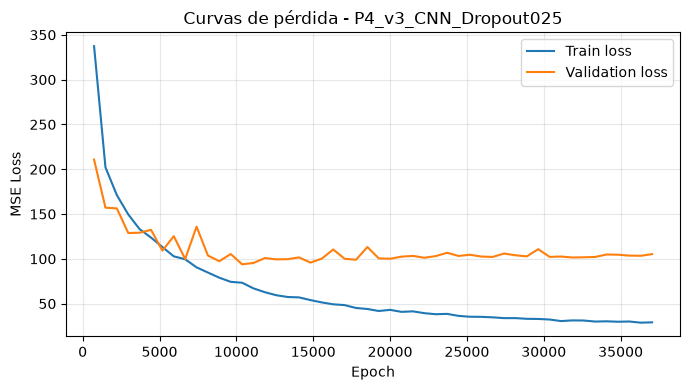

Figura guardada: figures_part4_v3/loss_P4_v3_CNN_Dropout025.png


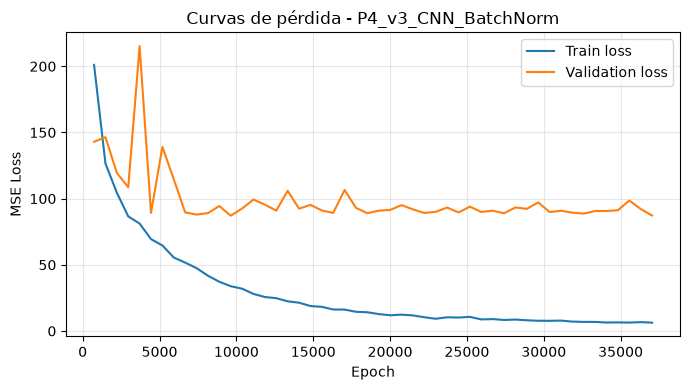

Figura guardada: figures_part4_v3/loss_P4_v3_CNN_BatchNorm.png


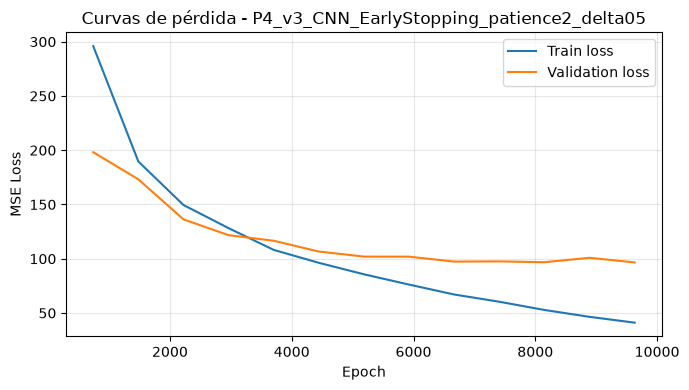

Figura guardada: figures_part4_v3/loss_P4_v3_CNN_EarlyStopping_patience2_delta05.png


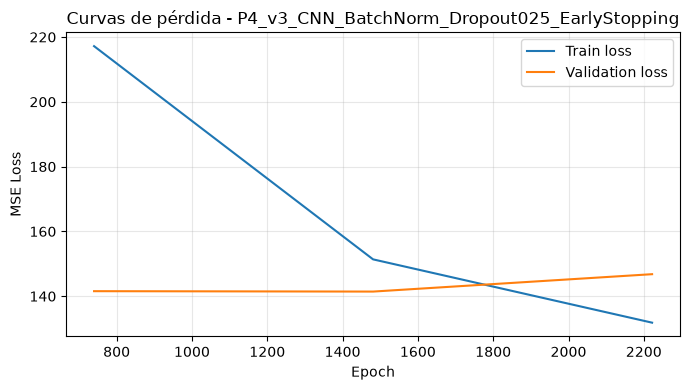

Figura guardada: figures_part4_v3/loss_P4_v3_CNN_BatchNorm_Dropout025_EarlyStopping.png


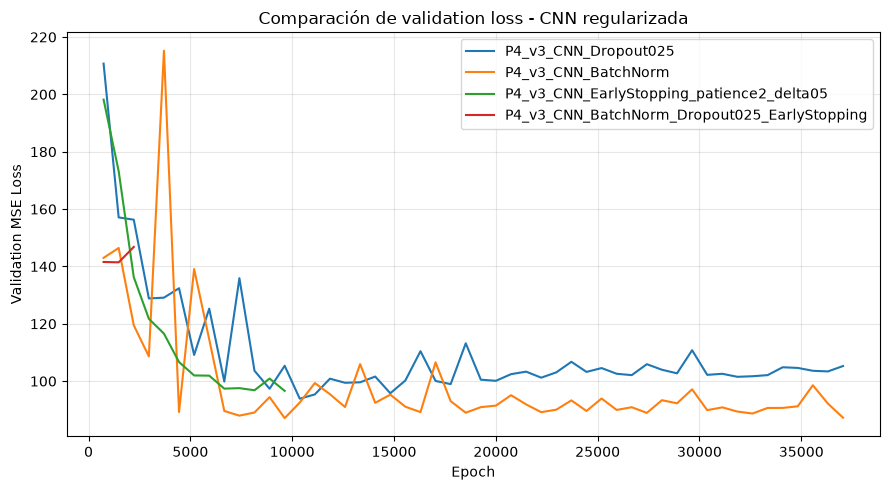

Figura guardada: figures_part4_v3/validation_loss_comparison.png


,run_name,run_id,train_mae,val_mae,test_mae,train_mse,val_mse,test_mse,use_batchnorm,use_dropout,dropout_p
2,P4_v3_CNN_BatchNorm,bcd08ea1e30a46a08b6c5fc81e05c992,1.568974,6.714406,6.955759,4.807241,87.263489,93.324844,True,False,0.25
1,P4_v3_CNN_EarlyStopping_patience2_delta05,e8c3fedac9e84479ae917ae052256606,4.332335,7.034936,7.269444,32.846516,96.611649,101.709908,False,False,0.25
3,P4_v3_CNN_Dropout025,2a6f67e915934386a5c8c4b61888e909,2.762477,7.292094,7.616944,13.581360,105.274460,110.693626,False,True,0.25
0,P4_v3_CNN_BatchNorm_Dropout025_EarlyStopping,218b2698a4f2453d9ad656608a3918ae,8.797892,9.455282,9.461952,125.467369,146.801315,148.991959,True,True,0.25


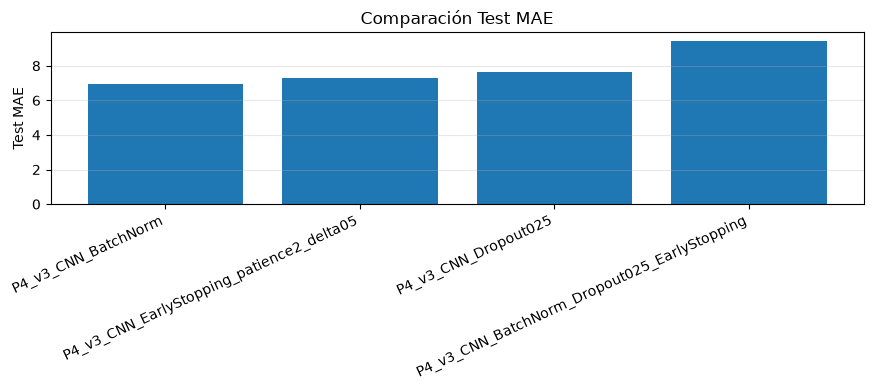

Figura guardada: figures_part4_v3/test_mae_comparison.png


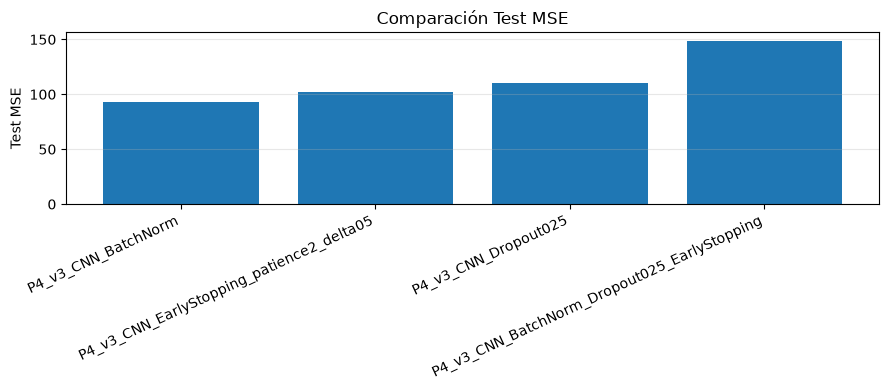

Figura guardada: figures_part4_v3/test_mse_comparison.png
Mejor estrategia según Test MAE: P4_v3_CNN_BatchNorm


,y_true,y_pred,abs_error
0,18.0,23.537174,5.537174
1,68.0,64.855250,3.144753
2,6.0,9.041721,3.041721
3,27.0,22.643618,4.356382
4,28.0,35.042187,7.042187


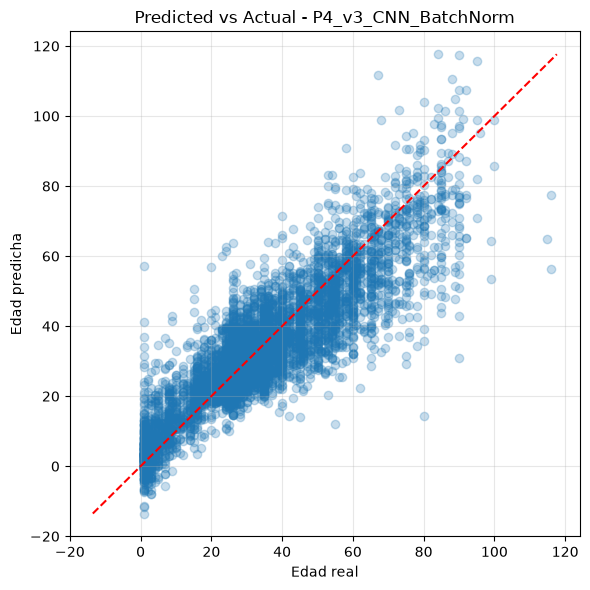

Figura guardada: figures_part4_v3/predicted_vs_actual_best_model.png


,age_range,min_age,max_age,n_samples,mae,mse
0,Ninos,0,12,839,5.678267,66.788361
1,Adolescentes,13,19,298,6.462366,73.741194
2,Adultos_jovenes,20,39,2981,5.214852,48.048180
3,Adultos,40,59,1096,8.766428,120.113605
4,Adultos_mayores,60,120,713,13.160526,280.855406


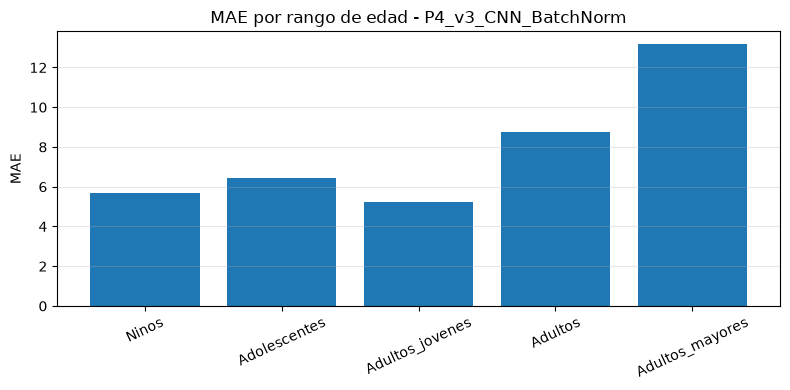

Figura guardada: figures_part4_v3/mae_by_age_range_best_model.png
Resumen para responder la consigna
Mejor estrategia según Test MAE: P4_v3_CNN_BatchNorm
Test MAE: 6.956
Test MSE: 93.325

Puntos cubiertos:
- Se compararon curvas train_loss y val_loss para cada estrategia.
- Se comparó validation loss entre estrategias.
- Se evaluaron MSE y MAE en train, validation y test.
- Se generó predicted vs actual usando predicciones guardadas.
- Se analizó MAE por rangos de edad.
- Se identificó la estrategia más efectiva según Test MAE.

Interpretación sugerida:
- De todas las combinaciones el modelo P4_v3_CNN_BatchNorm_Dropout025_EarlyStopping subajusta, los demas tienen distintos grados de overfiting.
- De todos los modelos testeados, el que mejor rendimiento mostro es P4_v3_CNN_BatchNorm en el conjunto de test
- El análisis por edad permite ver que P4_v3_CNN_BatchNorm se equivoca mas en adultos mayores


In [2]:
# ============================================================
# PARTE 4 - VISUALIZACION Y ANALISIS DESDE MLFLOW
# ============================================================
# Este bloque usa lo guardado en el experimento v3:
# - train_loss y val_loss por epoch
# - MSE/MAE finales en train, validation y test
# - predicciones de test guardadas como CSV
# - errores por rango de edad guardados como CSV
#
# Con esto se cubre:
# 1. Comparar curvas train/validation loss.
# 2. Analizar si bajó el overfitting.
# 3. Evaluar MSE y MAE en train/validation/test.
# 4. Comparar predicted vs actual ages.
# 5. Analizar desempeño por rangos de edad.
# 6. Discutir qué regularización fue más efectiva.
# ============================================================

from pathlib import Path

import mlflow
from mlflow.tracking import MlflowClient

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Configuración de MLflow
# ============================================================

TRACKING_URI = "sqlite:///mlruns/mlflow.db"
EXPERIMENT = "UTKFace_Age_Regression_Part4_Regularization_v3"

mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient(tracking_uri=TRACKING_URI)

Path("figures_part4_v3").mkdir(exist_ok=True)


# ============================================================
# 2. Recuperar runs del experimento
# ============================================================
# Parte cubierta:
# - Recuperar las ejecuciones de las estrategias de regularización.
# ============================================================

def get_experiment_runs(experiment_name=EXPERIMENT):
    """
    Recupera todos los runs del experimento indicado.
    """

    experiment = mlflow.get_experiment_by_name(experiment_name)

    if experiment is None:
        raise ValueError(f"No existe el experimento: {experiment_name}")

    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        output_format="pandas"
    )

    runs = runs.sort_values("start_time", ascending=True)

    return runs


runs_df = get_experiment_runs()

display_cols = [
    "run_id",
    "tags.mlflow.runName",
    "status",
    "metrics.train_mae_final",
    "metrics.val_mae_final",
    "metrics.test_mae_final",
    "metrics.train_mse_final",
    "metrics.val_mse_final",
    "metrics.test_mse_final",
    "params.use_batchnorm",
    "params.use_dropout",
    "params.dropout_p"
]

available_cols = [col for col in display_cols if col in runs_df.columns]
display(runs_df[available_cols])


# ============================================================
# 3. Funciones auxiliares para métricas históricas
# ============================================================

def get_metric_history(run_id, metric_name):
    """
    Recupera una métrica histórica desde MLflow.
    Por ejemplo:
    - train_loss
    - val_loss
    """

    history = client.get_metric_history(run_id, metric_name)

    steps = [m.step for m in history]
    values = [m.value for m in history]

    return steps, values


# ============================================================
# 4. Curvas individuales train_loss vs val_loss
# ============================================================
# Parte cubierta:
# - Compare the training and validation loss curves.
# - Did overfitting reduce?
# - Did training become more stable?
# ============================================================

def plot_individual_loss_curves(runs_df):
    """
    Genera una figura por estrategia con train_loss y val_loss.
    """

    for _, row in runs_df.iterrows():
        run_id = row["run_id"]
        run_name = row["tags.mlflow.runName"]

        train_steps, train_loss = get_metric_history(run_id, "train_loss")
        val_steps, val_loss = get_metric_history(run_id, "val_loss")

        fig, ax = plt.subplots(figsize=(7, 4))

        ax.plot(train_steps, train_loss, label="Train loss")
        ax.plot(val_steps, val_loss, label="Validation loss")

        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE Loss")
        ax.set_title(f"Curvas de pérdida - {run_name}")
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()

        filename = f"figures_part4_v3/loss_{run_name}.png"
        plt.savefig(filename, dpi=120)
        plt.show()
        plt.close(fig)

        print("Figura guardada:", filename)


plot_individual_loss_curves(runs_df)


# ============================================================
# 5. Comparación conjunta de validation loss
# ============================================================
# Parte cubierta:
# - Comparar las estrategias entre sí.
# - Ver cuál reduce mejor la pérdida de validación.
# ============================================================

def plot_validation_loss_comparison(runs_df):
    """
    Grafica val_loss de todos los runs en la misma figura.
    """

    fig, ax = plt.subplots(figsize=(9, 5))

    for _, row in runs_df.iterrows():
        run_id = row["run_id"]
        run_name = row["tags.mlflow.runName"]

        val_steps, val_loss = get_metric_history(run_id, "val_loss")
        ax.plot(val_steps, val_loss, label=run_name)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation MSE Loss")
    ax.set_title("Comparación de validation loss - CNN regularizada")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()

    filename = "figures_part4_v3/validation_loss_comparison.png"
    plt.savefig(filename, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", filename)


plot_validation_loss_comparison(runs_df)


# ============================================================
# 6. Tabla de métricas finales
# ============================================================
# Parte cubierta:
# - Evaluate performance using MSE and MAE on train, validation and test.
# ============================================================

def build_metrics_table(runs_df):
    """
    Construye una tabla con MSE y MAE finales.
    """

    table = pd.DataFrame({
        "run_name": runs_df["tags.mlflow.runName"],
        "run_id": runs_df["run_id"],
        "train_mae": runs_df["metrics.train_mae_final"],
        "val_mae": runs_df["metrics.val_mae_final"],
        "test_mae": runs_df["metrics.test_mae_final"],
        "train_mse": runs_df["metrics.train_mse_final"],
        "val_mse": runs_df["metrics.val_mse_final"],
        "test_mse": runs_df["metrics.test_mse_final"],
        "use_batchnorm": runs_df.get("params.use_batchnorm", None),
        "use_dropout": runs_df.get("params.use_dropout", None),
        "dropout_p": runs_df.get("params.dropout_p", None)
    })

    table = table.sort_values("test_mae", ascending=True)

    return table


metrics_table = build_metrics_table(runs_df)
display(metrics_table)


# ============================================================
# 7. Gráficos de MAE y MSE finales
# ============================================================
# Parte cubierta:
# - Comparar qué técnica generaliza mejor.
# - MAE se interpreta como error promedio en años.
# ============================================================

def plot_metric_bar(metrics_table, metric_name, title, ylabel, filename):
    """
    Grafica una métrica final por estrategia.
    """

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.bar(metrics_table["run_name"], metrics_table[metric_name])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    output_path = f"figures_part4_v3/{filename}"
    plt.savefig(output_path, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", output_path)


plot_metric_bar(
    metrics_table,
    metric_name="test_mae",
    title="Comparación Test MAE",
    ylabel="Test MAE",
    filename="test_mae_comparison.png"
)

plot_metric_bar(
    metrics_table,
    metric_name="test_mse",
    title="Comparación Test MSE",
    ylabel="Test MSE",
    filename="test_mse_comparison.png"
)


# ============================================================
# 8. Descargar predicciones guardadas desde MLflow
# ============================================================
# Parte cubierta:
# - Predicted vs actual ages.
# - Performance across different age ranges.
# ============================================================

def find_csv_artifact(run_id, artifact_folder):
    """
    Busca un archivo CSV dentro de una carpeta de artefactos de MLflow.
    """

    artifacts = client.list_artifacts(run_id, artifact_folder)

    for artifact in artifacts:
        if artifact.path.endswith(".csv"):
            return artifact.path

    return None


def download_csv_artifact(run_id, artifact_folder):
    """
    Descarga un CSV guardado como artefacto y lo devuelve como DataFrame.
    """

    artifact_path = find_csv_artifact(run_id, artifact_folder)

    if artifact_path is None:
        return None

    local_path = client.download_artifacts(run_id, artifact_path)
    return pd.read_csv(local_path)


# ============================================================
# 9. Predicted vs actual para el mejor modelo
# ============================================================
# Parte cubierta:
# - Compare predicted vs actual ages on test samples.
# ============================================================

best_row = metrics_table.iloc[0]
best_run_id = best_row["run_id"]
best_run_name = best_row["run_name"]

print("Mejor estrategia según Test MAE:", best_run_name)

best_predictions = download_csv_artifact(
    best_run_id,
    artifact_folder="predictions"
)

if best_predictions is not None:
    display(best_predictions.head())

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        best_predictions["y_true"],
        best_predictions["y_pred"],
        alpha=0.25
    )

    min_age = min(best_predictions["y_true"].min(), best_predictions["y_pred"].min())
    max_age = max(best_predictions["y_true"].max(), best_predictions["y_pred"].max())

    ax.plot(
        [min_age, max_age],
        [min_age, max_age],
        color="red",
        linestyle="--"
    )

    ax.set_xlabel("Edad real")
    ax.set_ylabel("Edad predicha")
    ax.set_title(f"Predicted vs Actual - {best_run_name}")
    ax.grid(alpha=0.3)

    plt.tight_layout()

    filename = "figures_part4_v3/predicted_vs_actual_best_model.png"
    plt.savefig(filename, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", filename)
else:
    print("No se encontraron predicciones guardadas para el mejor run.")


# ============================================================
# 10. Error por rangos de edad
# ============================================================
# Parte cubierta:
# - Analyze how the model performs across different age ranges.
# ============================================================

best_age_ranges = download_csv_artifact(
    best_run_id,
    artifact_folder="age_ranges"
)

if best_age_ranges is not None:
    display(best_age_ranges)

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.bar(
        best_age_ranges["age_range"],
        best_age_ranges["mae"]
    )

    ax.set_ylabel("MAE")
    ax.set_title(f"MAE por rango de edad - {best_run_name}")
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=25)
    plt.tight_layout()

    filename = "figures_part4_v3/mae_by_age_range_best_model.png"
    plt.savefig(filename, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", filename)
else:
    print("No se encontraron errores por rango de edad guardados.")


# ============================================================
# 11. Interpretación automática breve
# ============================================================
# Parte cubierta:
# - Discuss which regularization techniques were most effective.
# ============================================================

best_test_mae = best_row["test_mae"]
best_test_mse = best_row["test_mse"]

print("=" * 100)
print("Resumen para responder la consigna")
print("=" * 100)

print(f"Mejor estrategia según Test MAE: {best_run_name}")
print(f"Test MAE: {best_test_mae:.3f}")
print(f"Test MSE: {best_test_mse:.3f}")

print()
print("Puntos cubiertos:")
print("- Se compararon curvas train_loss y val_loss para cada estrategia.")
print("- Se comparó validation loss entre estrategias.")
print("- Se evaluaron MSE y MAE en train, validation y test.")
print("- Se generó predicted vs actual usando predicciones guardadas.")
print("- Se analizó MAE por rangos de edad.")
print("- Se identificó la estrategia más efectiva según Test MAE.")

print()
print("Interpretación sugerida:")
print("- De todas las combinaciones el modelo P4_v3_CNN_BatchNorm_Dropout025_EarlyStopping subajusta, los demas tienen distintos grados de overfiting.")
print("- De todos los modelos testeados, el que mejor rendimiento mostro es P4_v3_CNN_BatchNorm en el conjunto de test")
print("- El análisis por edad permite ver que P4_v3_CNN_BatchNorm se equivoca mas en adultos mayores")
print("=" * 100)

## 5. Data Augmentation to Improve Generalization

In this section, you will explore **Data Augmentation** as a technique to reduce overfitting, especially when training deep models on relatively small datasets. Data Augmentation artificially increases the diversity of the training data by applying random transformations to the original images. This helps the model become more robust by exposing it to a wider variety of visual scenarios during training.

Common image transformations include:

- **Rotation**: Randomly rotating the image by a few degrees.
- **Horizontal Flip**: Mirroring the image to simulate left/right variation.
- **Brightness and Contrast Adjustment**: Introducing lighting variability.
- **Random Resized Crop**: Cropping random portions of the image and resizing them, encouraging the model to focus on multiple parts of the object.

These augmentations help the model generalize better by reducing its reliance on specific patterns or image positions.

We will use the `torchvision.transforms.v2` module to apply these transformations. A typical transformation pipeline might look like this:

```python
import torchvision.transforms.v2 as v2

transform = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(20),
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.RandomResizedCrop(64, scale=(0.8, 1.0)),
])
```

You should now update your custom dataset class to apply these transformations to the training data only. Then, define new DataLoaders for training, validation, and test sets accordingly.

**Use the best model from the previous section** (i.e., your CNN including the best regularization strategies like dropout, batch normalization, and early stopping) and train it again using the augmented data. Compare its performance to the previous version trained without augmentation.

**Discussion**: Try different combinations of transformations and vary their parameters (e.g., rotation angle, brightness factor, scale range). Discuss which ones seem most appropriate for this task and why. Are there any transformations that seem to harm performance or introduce unrealistic samples?

In [4]:
# ============================================================
# PARTE 5 - DATA AUGMENTATION PARA MEJORAR GENERALIZACION
# ============================================================
# Objetivo:
# - Aplicar data augmentation SOLO al conjunto de entrenamiento.
# - Mantener validation y test sin augmentation.
# - Usar como base el mejor modelo anterior: CNN con BatchNorm.
# - Usar EarlyStopping para ahorrar tiempo y reducir overfitting.
# - Guardar en MLflow:
#   - curvas train_loss / val_loss
#   - MSE y MAE en train, validation y test
#   - predicciones de test como CSV
#   - errores por rango de edad como CSV
#
# Importante:
# - No se guardan modelos para ahorrar memoria.
# - Se guardan predicciones para poder responder predicted vs actual
#   y análisis por rango de edad sin reentrenar.
# ============================================================

import gc
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import pandas as pd

try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

from pytorch_lightning.loggers import MLFlowLogger
from pytorch_lightning.callbacks import EarlyStopping

import mlflow

import torchvision.transforms.v2 as v2


# ============================================================
# 1. Configuracion general
# ============================================================

# Usar las rutas correctas que ya confirmaste.
images_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_UTK_64x64.pt"
ages_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_ages_UTK.pt"

TRACKING_URI = "sqlite:///mlruns/mlflow.db"
EXPERIMENT = "UTKFace_Age_Regression_Part4_Regularization_v3"

Path("mlruns").mkdir(exist_ok=True)
Path("predictions_part5").mkdir(exist_ok=True)
Path("age_ranges_part5").mkdir(exist_ok=True)

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT)

SEED = 42
pl.seed_everything(SEED, workers=True)

batch_size = 16
max_epochs = 50
learning_rate = 1e-3

# Si el kernel queda justo, probar con 8000 o 12000.
MAX_SAMPLES = None

accelerator = "auto"
devices = "auto"
precision = "16-mixed" if torch.cuda.is_available() else "32-true"

print("CUDA disponible:", torch.cuda.is_available())
print("Precision:", precision)


# ============================================================
# 2. Transforms de Data Augmentation
# ============================================================
# Parte de la consigna cubierta:
# - Rotation
# - Horizontal Flip
# - Brightness / Contrast
# - Random Resized Crop
#
# Nota:
# - Estas transformaciones se aplican SOLO a train.
# - Validation y test quedan sin augmentation para medir generalizacion real.
# ============================================================

AUGMENTATION_CONFIGS = {
    "P5_Aug_Flip_Rotation": v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomRotation(degrees=15),
    ]),

    "P5_Aug_ColorJitter": v2.Compose([
        v2.ColorJitter(brightness=0.2, contrast=0.2),
    ]),

    "P5_Aug_Crop_Flip_Rotation": v2.Compose([
        v2.RandomResizedCrop(size=(64, 64), scale=(0.85, 1.0)),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomRotation(degrees=15),
    ]),

    "P5_Aug_All_Moderate": v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomRotation(degrees=15),
        v2.ColorJitter(brightness=0.15, contrast=0.15),
        v2.RandomResizedCrop(size=(64, 64), scale=(0.85, 1.0)),
    ]),
}


# ============================================================
# 3. Dataset custom con transform opcional
# ============================================================
# Parte de la consigna cubierta:
# - Actualizar Dataset para aplicar transformaciones.
# - Aplicarlas solo al conjunto de entrenamiento.
#
# Nota de memoria:
# - Cargamos tensores en CPU.
# - El transform se aplica por muestra en __getitem__.
# ============================================================

class UTKFaceDataset(Dataset):
    """
    Dataset custom para UTKFace desde tensores .pt.

    Permite recibir transformaciones opcionales.
    """

    def __init__(self, images, ages, transform=None):
        self.images = images
        self.ages = ages
        self.transform = transform

    def __getitem__(self, index):
        image = self.images[index]
        age = self.ages[index]

        if self.transform is not None:
            image = self.transform(image)

        return image.float(), age.float()

    def __len__(self):
        return self.ages.shape[0]


def load_tensors(images_path, ages_path, max_samples=None):
    """
    Carga tensores de imagenes y edades.
    Escala pixeles a [0, 1].
    """

    images = torch.load(images_path, map_location="cpu")
    ages = torch.load(ages_path, map_location="cpu")

    if max_samples is not None:
        images = images[:max_samples]
        ages = ages[:max_samples]

    images = images.to(torch.float32)

    if images.max() > 1:
        images = images / 255.0

    ages = ages.to(torch.float32)

    if ages.ndim == 1:
        ages = ages.view(-1, 1)

    return images, ages


# ============================================================
# 4. Crear DataLoaders con augmentation solo en train
# ============================================================

def create_augmented_dataloaders(train_transform=None, seed=42):
    """
    Crea DataLoaders reproducibles.

    - Train usa transform de augmentation.
    - Validation y test NO usan transform.
    """

    images, ages = load_tensors(
        images_path=images_path,
        ages_path=ages_path,
        max_samples=MAX_SAMPLES
    )

    base_dataset = UTKFaceDataset(images, ages, transform=None)

    dataset_size = len(base_dataset)

    train_size = int(0.50 * dataset_size)
    val_size = int(0.25 * dataset_size)
    test_size = dataset_size - train_size - val_size

    train_subset, val_subset, test_subset = random_split(
        base_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    # Creamos datasets separados que comparten los mismos tensores,
    # pero solo train recibe transform.
    train_dataset = UTKFaceDataset(images, ages, transform=train_transform)
    val_dataset = UTKFaceDataset(images, ages, transform=None)
    test_dataset = UTKFaceDataset(images, ages, transform=None)

    # Reutilizamos los indices del split original.
    train_dataset = torch.utils.data.Subset(train_dataset, train_subset.indices)
    val_dataset = torch.utils.data.Subset(val_dataset, val_subset.indices)
    test_dataset = torch.utils.data.Subset(test_dataset, test_subset.indices)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    return images, ages, train_loader, val_loader, test_loader


# ============================================================
# 5. CNN base: mejor modelo previo con BatchNorm
# ============================================================

class AgeCNNBatchNorm(nn.Module):
    """
    CNN para regresion de edad.

    Basada en el mejor modelo anterior:
    - 2 capas convolucionales
    - BatchNorm despues de cada convolucion
    - ReLU
    - MaxPool
    - FC 128
    - Salida 1
    """

    def __init__(self, input_channels=3):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


# ============================================================
# 6. LightningModule
# ============================================================

class LitAgeCNN(pl.LightningModule):
    """
    LightningModule para entrenar CNN con MSELoss.
    """

    def __init__(self, model, learning_rate=1e-3, augmentation_name="none"):
        super().__init__()

        self.save_hyperparameters(ignore=["model"])
        self.model = model
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        images, ages = batch

        ages = ages.float()
        if ages.ndim == 1:
            ages = ages.view(-1, 1)

        preds = self(images)
        loss = self.loss_fn(preds, ages)

        return loss, preds, ages

    def training_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "train_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "val_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def test_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "test_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.learning_rate
        )


# ============================================================
# 7. Evaluacion y artefactos
# ============================================================

def evaluate_regression_model(model, dataloader, device=None):
    """
    Calcula MSE, MAE, predicciones y valores reales.
    """

    if device is None:
        device = next(model.parameters()).device

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, ages in dataloader:
            images = images.to(device)
            ages = ages.to(device).float()

            if ages.ndim == 1:
                ages = ages.view(-1, 1)

            preds = model(images)

            all_preds.append(preds.detach().cpu())
            all_targets.append(ages.detach().cpu())

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    mse = F.mse_loss(all_preds, all_targets).item()
    mae = F.l1_loss(all_preds, all_targets).item()

    return {
        "mse": mse,
        "mae": mae,
        "preds": all_preds.numpy().flatten(),
        "targets": all_targets.numpy().flatten()
    }


def save_predictions_csv(metrics, output_path):
    """
    Guarda y_true, y_pred y abs_error en CSV.
    """

    df = pd.DataFrame({
        "y_true": metrics["targets"],
        "y_pred": metrics["preds"]
    })

    df["abs_error"] = np.abs(df["y_pred"] - df["y_true"])
    df.to_csv(output_path, index=False)

    return output_path


def compute_age_range_errors(predictions_csv, output_path):
    """
    Calcula MAE/MSE por rango de edad.
    """

    df = pd.read_csv(predictions_csv)

    age_bins = [
        (0, 12, "Ninos"),
        (13, 19, "Adolescentes"),
        (20, 39, "Adultos_jovenes"),
        (40, 59, "Adultos"),
        (60, 120, "Adultos_mayores")
    ]

    rows = []

    for min_age, max_age, label in age_bins:
        mask = (df["y_true"] >= min_age) & (df["y_true"] <= max_age)
        group = df[mask]

        if len(group) > 0:
            rows.append({
                "age_range": label,
                "min_age": min_age,
                "max_age": max_age,
                "n_samples": len(group),
                "mae": group["abs_error"].mean(),
                "mse": np.mean((group["y_pred"] - group["y_true"]) ** 2)
            })

    range_df = pd.DataFrame(rows)
    range_df.to_csv(output_path, index=False)

    return output_path


# ============================================================
# 8. Entrenar una configuracion de augmentation
# ============================================================
# EarlyStopping exigente:
# - patience=2
# - min_delta=0.5
# ============================================================

def run_augmentation_experiment(run_name, train_transform):
    """
    Entrena CNN BatchNorm con una estrategia de augmentation.
    """

    print("=" * 100)
    print("Entrenando:", run_name)
    print("=" * 100)

    images, ages, train_loader, val_loader, test_loader = create_augmented_dataloaders(
        train_transform=train_transform,
        seed=SEED
    )

    sample_images, _ = next(iter(train_loader))
    input_channels = sample_images.shape[1]

    base_model = AgeCNNBatchNorm(input_channels=input_channels)

    lit_model = LitAgeCNN(
        model=base_model,
        learning_rate=learning_rate,
        augmentation_name=run_name
    )

    mlf_logger = MLFlowLogger(
        experiment_name=EXPERIMENT,
        tracking_uri=TRACKING_URI,
        run_name=run_name
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=2,
        min_delta=0.5,
        mode="min",
        verbose=True
    )

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator=accelerator,
        devices=devices,
        precision=precision,
        deterministic=True,
        log_every_n_steps=25,
        logger=mlf_logger,
        callbacks=[early_stopping],
        enable_checkpointing=False
    )

    trainer.fit(
        lit_model,
        train_dataloaders=train_loader,
        val_dataloaders=val_loader
    )

    trainer.test(
        lit_model,
        dataloaders=test_loader
    )

    train_metrics = evaluate_regression_model(lit_model, train_loader)
    val_metrics = evaluate_regression_model(lit_model, val_loader)
    test_metrics = evaluate_regression_model(lit_model, test_loader)

    run_id = mlf_logger.run_id

    mlf_logger.experiment.log_metric(run_id, "train_mse_final", train_metrics["mse"])
    mlf_logger.experiment.log_metric(run_id, "train_mae_final", train_metrics["mae"])
    mlf_logger.experiment.log_metric(run_id, "val_mse_final", val_metrics["mse"])
    mlf_logger.experiment.log_metric(run_id, "val_mae_final", val_metrics["mae"])
    mlf_logger.experiment.log_metric(run_id, "test_mse_final", test_metrics["mse"])
    mlf_logger.experiment.log_metric(run_id, "test_mae_final", test_metrics["mae"])

    pred_path = f"predictions_part5/{run_name}_test_predictions.csv"
    range_path = f"age_ranges_part5/{run_name}_age_range_errors.csv"

    save_predictions_csv(test_metrics, pred_path)
    compute_age_range_errors(pred_path, range_path)

    mlf_logger.experiment.log_artifact(run_id, pred_path, artifact_path="predictions")
    mlf_logger.experiment.log_artifact(run_id, range_path, artifact_path="age_ranges")

    print("Run finalizado:", run_name)
    print("run_id:", run_id)
    print("Test MAE:", test_metrics["mae"])
    print("Test MSE:", test_metrics["mse"])

    del images, ages
    del train_loader, val_loader, test_loader
    del base_model, lit_model, trainer
    del train_metrics, val_metrics, test_metrics

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return run_id


# ============================================================
# 9. Ejecutar experimentos
# ============================================================
# Recomendacion:
# Si el kernel esta delicado, ejecutar uno por vez.
# ============================================================

PART5_RUN_IDS = {}

for run_name, transform in AUGMENTATION_CONFIGS.items():
    PART5_RUN_IDS[run_name] = run_augmentation_experiment(
        run_name=run_name,
        train_transform=transform
    )

print("Runs generados:")
print(PART5_RUN_IDS)

Seed set to 42


CUDA disponible: False
Precision: 32-true
Entrenando: P5_Aug_Flip_Rotation


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type            | Params | Mode  | FLOPs
------------------------------------------------------------
0 | model   | AgeCNNBatchNorm | 2.1 M  | train | 0    
1 | loss_fn | MSELoss         | 0      | train | 0    
------------------------------------------------------------
2.1 M     Trainable params
0         Non-trainable params
2.1 M     Total params
8.468     Total estimated model params size (MB)
16        Modules in train mode
0         Modules in eval mode
0         Total Flops


C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 741/741 [01:19<00:00,  9.27it/s, v_num=5c79]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 741/741 [01:33<00:00,  7.89it/s, v_num=5c79, val_loss=171.0]

...

Epoch 2: 100%|██████████| 741/741 [01:16<00:00,  9.74it/s, v_num=32e2, val_loss=179.0, train_loss=207.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 741/741 [01:16<00:00,  9.63it/s, v_num=32e2, val_loss=185.0, train_loss=181.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 741/741 [01:30<00:00,  8.22it/s, v_num=32e2, val_loss=219.0, train_loss=181.0]

Monitored metric val_loss did not improve in the last 2 records. Best score: 179.409. Signaling Trainer to stop.


Epoch 3: 100%|██████████| 741/741 [01:30<00:00,  8.22it/s, v_num=32e2, val_loss=219.0, train_loss=169.0]


C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 371/371 [00:12<00:00, 30.36it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           220.26541137695312
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Run finalizado: P5_Aug_All_Moderate
run_id: d3ec9cdd90dc48ea9132e706ba1132e2
Test MAE: 11.917553901672363
Test MSE: 220.26528930664062
Runs generados:
{'P5_Aug_Flip_Rotation': '6ff5c79662a74470888ee52bd14c5c79', 'P5_Aug_ColorJitter': 'a8caf32e1ede4f15bd38f67fb66471ac', 'P5_Aug_Crop_Flip_Rotation': '7179fcbb4de84636bc30038efc6e617a', 'P5_Aug_All_Moderate': 'd3ec9cdd90dc48ea9132e706ba1132e2'}


C:\Users\felix\.conda\envs\fraud-conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,run_id,tags.mlflow.runName,status,metrics.test_mae_final,metrics.test_mse_final,metrics.val_mae_final,metrics.val_mse_final
6,bcd08ea1e30a46a08b6c5fc81e05c992,P4_v3_CNN_BatchNorm,FINISHED,6.955759,93.324844,6.714406,87.263489
3,6ff5c79662a74470888ee52bd14c5c79,P5_Aug_Flip_Rotation,FINISHED,10.644701,188.661804,10.415631,183.260040
2,a8caf32e1ede4f15bd38f67fb66471ac,P5_Aug_ColorJitter,FINISHED,7.850194,108.337364,7.608875,101.493713
1,7179fcbb4de84636bc30038efc6e617a,P5_Aug_Crop_Flip_Rotation,FINISHED,13.258554,279.548431,13.135437,272.808777
0,d3ec9cdd90dc48ea9132e706ba1132e2,P5_Aug_All_Moderate,FINISHED,11.917554,220.265289,11.936134,219.073868


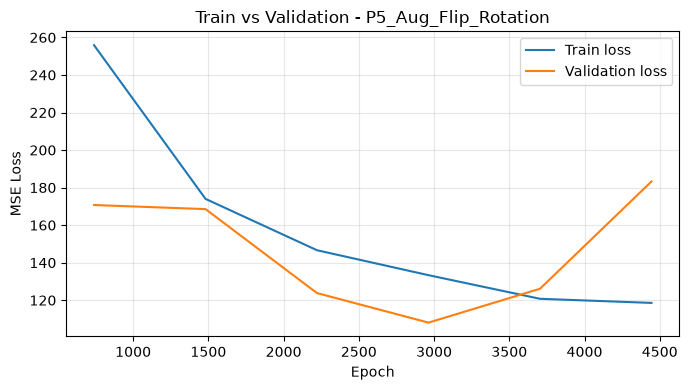

Figura guardada: figures_part5_aug_analysis/loss_P5_Aug_Flip_Rotation.png


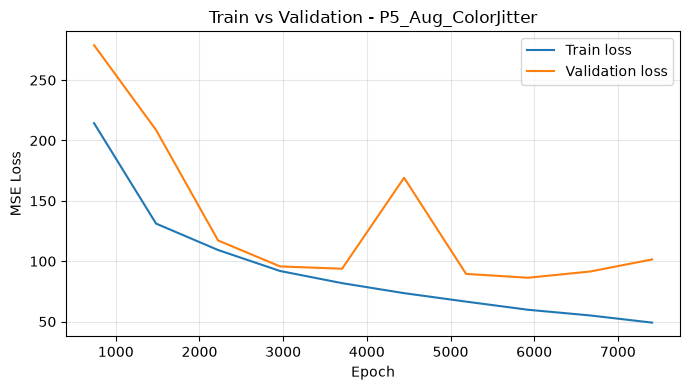

Figura guardada: figures_part5_aug_analysis/loss_P5_Aug_ColorJitter.png


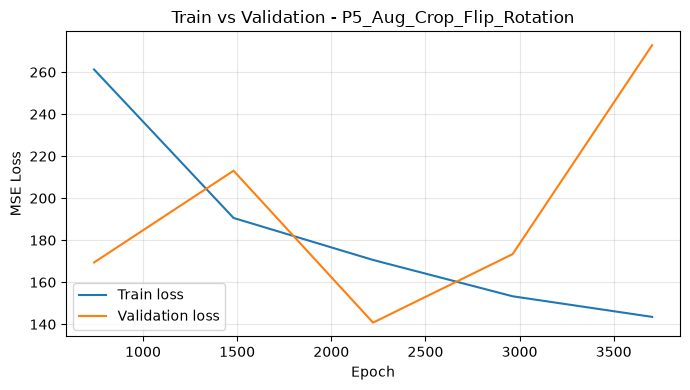

Figura guardada: figures_part5_aug_analysis/loss_P5_Aug_Crop_Flip_Rotation.png


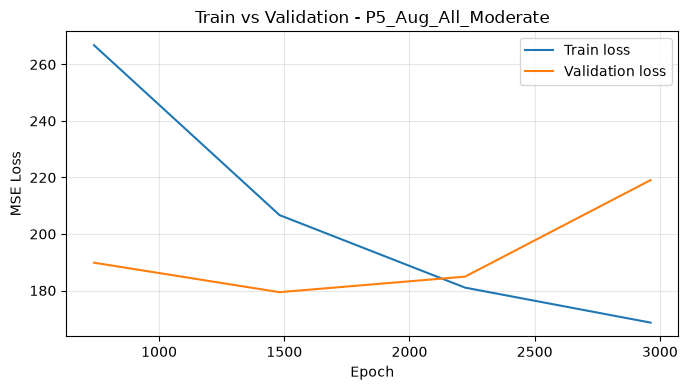

Figura guardada: figures_part5_aug_analysis/loss_P5_Aug_All_Moderate.png


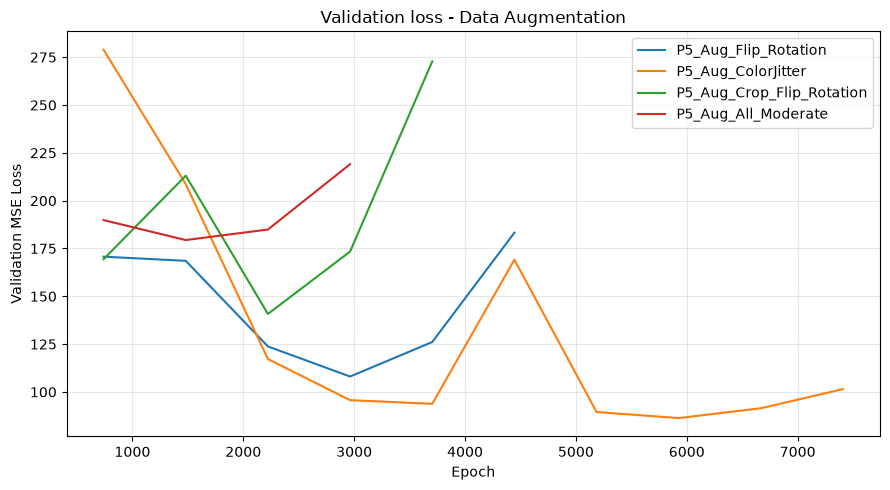

Figura guardada: figures_part5_aug_analysis/validation_loss_aug_comparison.png


,run_name,run_id,test_mae,test_mse,val_mae,val_mse,type
0,P4_v3_CNN_BatchNorm,bcd08ea1e30a46a08b6c5fc81e05c992,6.955759,93.324844,6.714406,87.263489,No augmentation baseline
2,P5_Aug_ColorJitter,a8caf32e1ede4f15bd38f67fb66471ac,7.850194,108.337364,7.608875,101.493713,Data augmentation
1,P5_Aug_Flip_Rotation,6ff5c79662a74470888ee52bd14c5c79,10.644701,188.661804,10.415631,183.260040,Data augmentation
4,P5_Aug_All_Moderate,d3ec9cdd90dc48ea9132e706ba1132e2,11.917554,220.265289,11.936134,219.073868,Data augmentation
3,P5_Aug_Crop_Flip_Rotation,7179fcbb4de84636bc30038efc6e617a,13.258554,279.548431,13.135437,272.808777,Data augmentation


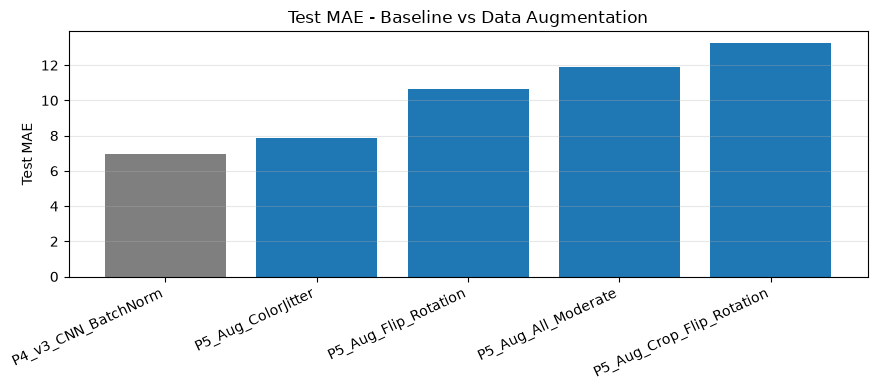

Figura guardada: figures_part5_aug_analysis/test_mae_baseline_vs_aug.png


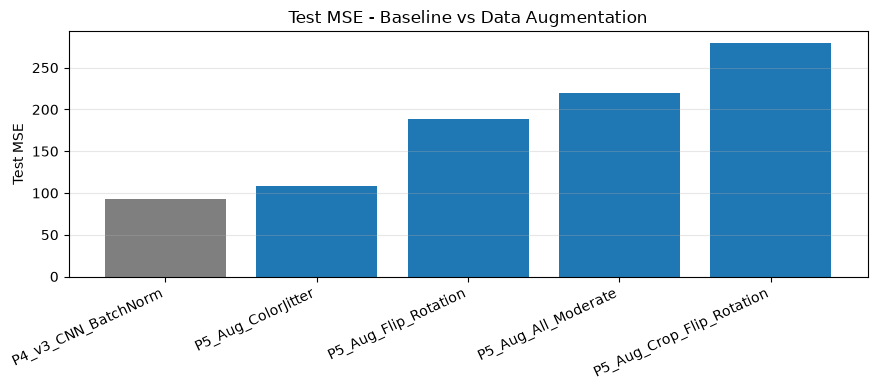

Figura guardada: figures_part5_aug_analysis/test_mse_baseline_vs_aug.png
Mejor run con augmentation: P5_Aug_ColorJitter
Test MAE: 7.850193500518799
Test MSE: 108.33736419677734


,y_true,y_pred,abs_error
0,18.0,27.794949,9.794949
1,68.0,69.552780,1.552780
2,6.0,11.828816,5.828816
3,27.0,25.039963,1.960037
4,28.0,39.985294,11.985294


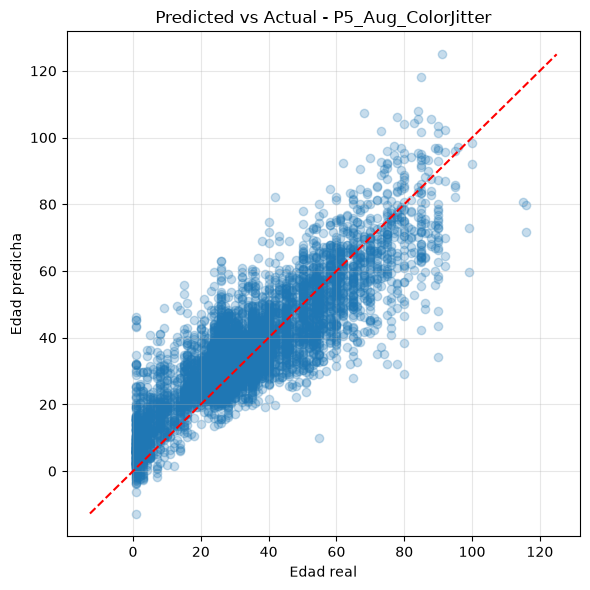

Figura guardada: figures_part5_aug_analysis/predicted_vs_actual_best_aug.png


,age_range,min_age,max_age,n_samples,mae,mse
0,Ninos,0,12,839,9.061274,139.395898
1,Adolescentes,13,19,298,9.925154,148.108497
2,Adultos_jovenes,20,39,2981,6.254642,69.369564
3,Adultos,40,59,1096,8.150850,103.225164
4,Adultos_mayores,60,120,713,11.766580,225.947586


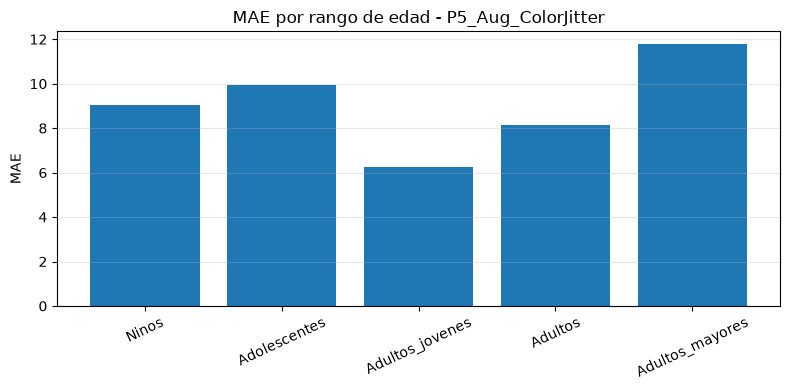

Figura guardada: figures_part5_aug_analysis/mae_by_age_range_best_aug.png
Resumen para responder la consigna de Data Augmentation
Baseline sin augmentation: P4_v3_CNN_BatchNorm
Baseline Test MAE: 6.956
Baseline Test MSE: 93.325

Mejor modelo con augmentation: P5_Aug_ColorJitter
Augmentation Test MAE: 7.850
Augmentation Test MSE: 108.337

Resultado: data augmentation no mejoró el MAE respecto del baseline sin augmentation.

Qué se comparó:
- Curvas train_loss y val_loss de cada configuración con augmentation.
- Validation loss entre configuraciones de augmentation.
- Test MAE y Test MSE contra el baseline sin augmentation.
- Predicted vs actual del mejor modelo con augmentation.
- MAE por rango de edad del mejor modelo con augmentation.

Discusión sugerida:
- Horizontal flip suele ser razonable para rostros porque conserva identidad facial general.
- Rotaciones moderadas pueden mejorar robustez; rotaciones fuertes podrían crear caras poco realistas.
- ColorJitter puede simular cambios d

In [1]:
# ============================================================
# PARTE 5 - VISUALIZACION DATA AUGMENTATION DESDE MLFLOW
# ============================================================
# Experimento usado:
# "UTKm Face_Age_Regression_Part4_Regularization_v3"
#
# Objetivo:
# - Mostrar SOLO lo necesario para responder la consigna de Data Augmentation.
# - Comparar modelos con augmentation contra el mejor modelo previo sin augmentation:
#   P4_v3_CNN_BatchNorm.
# ============================================================

from pathlib import Path

import mlflow
from mlflow.tracking import MlflowClient

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Configuración
# ============================================================

TRACKING_URI = "sqlite:///mlruns/mlflow.db"
EXPERIMENT = "UTKFace_Age_Regression_Part4_Regularization_v3"

mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient(tracking_uri=TRACKING_URI)

Path("figures_part5_aug_analysis").mkdir(exist_ok=True)


# ============================================================
# 2. Definir qué runs entran en el análisis
# ============================================================
# Solo analizamos:
# - Baseline previo sin augmentation: P4_v3_CNN_BatchNorm
# - Runs de Part 5 con augmentation: nombres que empiezan con P5_Aug
# ============================================================

BASELINE_RUN_NAME = "P4_v3_CNN_BatchNorm"
AUG_PREFIX = "P5_Aug"


def get_relevant_runs(experiment_name=EXPERIMENT):
    """
    Recupera runs del experimento y filtra:
    - baseline sin augmentation
    - runs de augmentation
    """

    experiment = mlflow.get_experiment_by_name(experiment_name)

    if experiment is None:
        raise ValueError(f"No existe el experimento: {experiment_name}")

    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        output_format="pandas"
    )

    runs = runs.copy()

    run_names = runs["tags.mlflow.runName"]

    relevant = runs[
        (run_names == BASELINE_RUN_NAME) |
        (run_names.str.startswith(AUG_PREFIX, na=False))
    ].copy()

    relevant = relevant.sort_values("start_time", ascending=True)

    return relevant


runs_df = get_relevant_runs()

display_cols = [
    "run_id",
    "tags.mlflow.runName",
    "status",
    "metrics.test_mae_final",
    "metrics.test_mse_final",
    "metrics.val_mae_final",
    "metrics.val_mse_final"
]

available_cols = [col for col in display_cols if col in runs_df.columns]
display(runs_df[available_cols])


# ============================================================
# 3. Separar baseline y runs con augmentation
# ============================================================

baseline_df = runs_df[runs_df["tags.mlflow.runName"] == BASELINE_RUN_NAME].copy()
aug_df = runs_df[runs_df["tags.mlflow.runName"].str.startswith(AUG_PREFIX, na=False)].copy()

if len(baseline_df) == 0:
    raise ValueError(f"No se encontró el baseline: {BASELINE_RUN_NAME}")

if len(aug_df) == 0:
    raise ValueError(f"No se encontraron runs de augmentation con prefijo: {AUG_PREFIX}")

# Si hay varios baseline con el mismo nombre, usamos el más reciente.
baseline_df = baseline_df.sort_values("start_time", ascending=False).head(1)

# Si hay varios runs con el mismo nombre, usamos el más reciente de cada configuración.
aug_df = aug_df.sort_values("start_time", ascending=False)
aug_df = aug_df.drop_duplicates(subset=["tags.mlflow.runName"], keep="first")
aug_df = aug_df.sort_values("start_time", ascending=True)


# ============================================================
# 4. Curvas train_loss vs val_loss SOLO para augmentation
# ============================================================
# Parte cubierta:
# - Analizar si data augmentation reduce overfitting.
# - Ver estabilidad de entrenamiento.
# ============================================================

def get_metric_history(run_id, metric_name):
    history = client.get_metric_history(run_id, metric_name)
    steps = [m.step for m in history]
    values = [m.value for m in history]
    return steps, values


def plot_aug_loss_curves(aug_df):
    """
    Grafica train_loss y val_loss para cada estrategia de augmentation.
    """

    for _, row in aug_df.iterrows():
        run_id = row["run_id"]
        run_name = row["tags.mlflow.runName"]

        train_steps, train_loss = get_metric_history(run_id, "train_loss")
        val_steps, val_loss = get_metric_history(run_id, "val_loss")

        fig, ax = plt.subplots(figsize=(7, 4))

        ax.plot(train_steps, train_loss, label="Train loss")
        ax.plot(val_steps, val_loss, label="Validation loss")

        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE Loss")
        ax.set_title(f"Train vs Validation - {run_name}")
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()

        filename = f"figures_part5_aug_analysis/loss_{run_name}.png"
        plt.savefig(filename, dpi=120)
        plt.show()
        plt.close(fig)

        print("Figura guardada:", filename)


plot_aug_loss_curves(aug_df)


# ============================================================
# 5. Comparación de validation loss entre augmentations
# ============================================================
# Parte cubierta:
# - Comparar combinaciones de transforms.
# - Ver cuál converge mejor en validation.
# ============================================================

def plot_aug_validation_comparison(aug_df):
    """
    Compara validation loss entre runs de augmentation.
    """

    fig, ax = plt.subplots(figsize=(9, 5))

    for _, row in aug_df.iterrows():
        run_id = row["run_id"]
        run_name = row["tags.mlflow.runName"]

        val_steps, val_loss = get_metric_history(run_id, "val_loss")
        ax.plot(val_steps, val_loss, label=run_name)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation MSE Loss")
    ax.set_title("Validation loss - Data Augmentation")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()

    filename = "figures_part5_aug_analysis/validation_loss_aug_comparison.png"
    plt.savefig(filename, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", filename)


plot_aug_validation_comparison(aug_df)


# ============================================================
# 6. Tabla comparativa: baseline vs augmentation
# ============================================================
# Parte cubierta:
# - Comparar performance del mejor modelo previo vs augmentation.
# - Usar MSE y MAE.
# ============================================================

def build_comparison_table(baseline_df, aug_df):
    """
    Construye tabla comparativa con métricas finales.
    """

    combined = pd.concat([baseline_df, aug_df], ignore_index=True)

    table = pd.DataFrame({
        "run_name": combined["tags.mlflow.runName"],
        "run_id": combined["run_id"],
        "test_mae": combined["metrics.test_mae_final"],
        "test_mse": combined["metrics.test_mse_final"],
        "val_mae": combined["metrics.val_mae_final"],
        "val_mse": combined["metrics.val_mse_final"],
    })

    table["type"] = table["run_name"].apply(
        lambda name: "No augmentation baseline" if name == BASELINE_RUN_NAME else "Data augmentation"
    )

    table = table.sort_values("test_mae", ascending=True)

    return table


comparison_table = build_comparison_table(baseline_df, aug_df)
display(comparison_table)


# ============================================================
# 7. Gráficos Test MAE y Test MSE
# ============================================================
# Parte cubierta:
# - Determinar si data augmentation mejora la generalización.
# ============================================================

def plot_metric_bar(table, metric_name, title, ylabel, filename):
    fig, ax = plt.subplots(figsize=(9, 4))

    colors = [
        "tab:gray" if t == "No augmentation baseline" else "tab:blue"
        for t in table["type"]
    ]

    ax.bar(table["run_name"], table[metric_name], color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    output_path = f"figures_part5_aug_analysis/{filename}"
    plt.savefig(output_path, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", output_path)


plot_metric_bar(
    comparison_table,
    metric_name="test_mae",
    title="Test MAE - Baseline vs Data Augmentation",
    ylabel="Test MAE",
    filename="test_mae_baseline_vs_aug.png"
)

plot_metric_bar(
    comparison_table,
    metric_name="test_mse",
    title="Test MSE - Baseline vs Data Augmentation",
    ylabel="Test MSE",
    filename="test_mse_baseline_vs_aug.png"
)


# ============================================================
# 8. Predicted vs actual del mejor modelo con augmentation
# ============================================================
# Parte cubierta:
# - Comparar predicted vs actual ages.
# ============================================================

def find_csv_artifact(run_id, artifact_folder):
    artifacts = client.list_artifacts(run_id, artifact_folder)

    for artifact in artifacts:
        if artifact.path.endswith(".csv"):
            return artifact.path

    return None


def download_csv_artifact(run_id, artifact_folder):
    artifact_path = find_csv_artifact(run_id, artifact_folder)

    if artifact_path is None:
        return None

    local_path = client.download_artifacts(run_id, artifact_path)
    return pd.read_csv(local_path)


best_aug_df = aug_df.sort_values("metrics.test_mae_final", ascending=True).head(1)
best_aug_run_id = best_aug_df.iloc[0]["run_id"]
best_aug_run_name = best_aug_df.iloc[0]["tags.mlflow.runName"]
best_aug_test_mae = best_aug_df.iloc[0]["metrics.test_mae_final"]
best_aug_test_mse = best_aug_df.iloc[0]["metrics.test_mse_final"]

print("Mejor run con augmentation:", best_aug_run_name)
print("Test MAE:", best_aug_test_mae)
print("Test MSE:", best_aug_test_mse)

best_predictions = download_csv_artifact(
    best_aug_run_id,
    artifact_folder="predictions"
)

if best_predictions is not None:
    display(best_predictions.head())

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        best_predictions["y_true"],
        best_predictions["y_pred"],
        alpha=0.25
    )

    min_age = min(best_predictions["y_true"].min(), best_predictions["y_pred"].min())
    max_age = max(best_predictions["y_true"].max(), best_predictions["y_pred"].max())

    ax.plot([min_age, max_age], [min_age, max_age], color="red", linestyle="--")

    ax.set_xlabel("Edad real")
    ax.set_ylabel("Edad predicha")
    ax.set_title(f"Predicted vs Actual - {best_aug_run_name}")
    ax.grid(alpha=0.3)

    plt.tight_layout()

    filename = "figures_part5_aug_analysis/predicted_vs_actual_best_aug.png"
    plt.savefig(filename, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", filename)
else:
    print("No se encontraron predicciones guardadas para el mejor run con augmentation.")


# ============================================================
# 9. MAE por rango de edad del mejor augmentation
# ============================================================
# Parte cubierta:
# - Analizar en qué edades el modelo falla más.
# ============================================================

best_age_ranges = download_csv_artifact(
    best_aug_run_id,
    artifact_folder="age_ranges"
)

if best_age_ranges is not None:
    display(best_age_ranges)

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.bar(best_age_ranges["age_range"], best_age_ranges["mae"])

    ax.set_ylabel("MAE")
    ax.set_title(f"MAE por rango de edad - {best_aug_run_name}")
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=25)
    plt.tight_layout()

    filename = "figures_part5_aug_analysis/mae_by_age_range_best_aug.png"
    plt.savefig(filename, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", filename)
else:
    print("No se encontraron errores por rango de edad para el mejor run con augmentation.")


# ============================================================
# 10. Resumen interpretativo
# ============================================================
# Parte cubierta:
# - Discussion: qué augmentation funcionó mejor y por qué.
# ============================================================

baseline_row = baseline_df.iloc[0]
baseline_test_mae = baseline_row["metrics.test_mae_final"]
baseline_test_mse = baseline_row["metrics.test_mse_final"]

print("=" * 100)
print("Resumen para responder la consigna de Data Augmentation")
print("=" * 100)

print(f"Baseline sin augmentation: {BASELINE_RUN_NAME}")
print(f"Baseline Test MAE: {baseline_test_mae:.3f}")
print(f"Baseline Test MSE: {baseline_test_mse:.3f}")

print()
print(f"Mejor modelo con augmentation: {best_aug_run_name}")
print(f"Augmentation Test MAE: {best_aug_test_mae:.3f}")
print(f"Augmentation Test MSE: {best_aug_test_mse:.3f}")

print()
if best_aug_test_mae < baseline_test_mae:
    print("Resultado: data augmentation mejoró el MAE respecto del baseline sin augmentation.")
else:
    print("Resultado: data augmentation no mejoró el MAE respecto del baseline sin augmentation.")

print()
print("Qué se comparó:")
print("- Curvas train_loss y val_loss de cada configuración con augmentation.")
print("- Validation loss entre configuraciones de augmentation.")
print("- Test MAE y Test MSE contra el baseline sin augmentation.")
print("- Predicted vs actual del mejor modelo con augmentation.")
print("- MAE por rango de edad del mejor modelo con augmentation.")

print()
print("Discusión sugerida:")
print("- Horizontal flip suele ser razonable para rostros porque conserva identidad facial general.")
print("- Rotaciones moderadas pueden mejorar robustez; rotaciones fuertes podrían crear caras poco realistas.")
print("- ColorJitter puede simular cambios de iluminación, pero si es excesivo puede distorsionar señales de edad.")
print("- RandomResizedCrop puede ayudar a robustez espacial, aunque crops agresivos pueden eliminar rasgos relevantes.")
print("- La mejor transformación debe juzgarse por menor Test MAE/Test MSE y por curvas validation más estables.")
print("=" * 100)



## 6. Data Augmentation for Balancing Age Ranges

As you likely noticed, the dataset may be imbalanced across different age ranges, which could lead to your model performing worse on underrepresented groups (e.g., older individuals). To help balance the data, we will use data augmentation to generate additional images for underrepresented age ranges.

**Strategy for Balancing the Dataset**:

- Analyze underrepresented age groups: First, you need to check the distribution of ages across the dataset to identify which age groups are underrepresented. You can use age groups in intervals of 10 years.

- Generate additional images for these age groups: Make copies of the data within each range to have a minimum of 2000 or 3000 samples per age group, so that the distribution becomes more homogeneous across all ranges.

- Generate diversity: Modify the code so that when loading each sample (in the dataset __getitem__), the samples are randomly modified to generate diversity among them, using the transformations defined earlier.

Retrain the CNN model with this extended dataset and verify that by generating more data for underrepresented age ranges, your model will not be biased towards ages with more training data.


Cantidad total de edades: 23705
Edad minima: 1.0
Edad maxima: 116.0
Edad media: 33.300907
Edad mediana: 29.0


,age_group,n_samples,percentage
0,0-9,3062,12.917106
1,10-19,1531,6.458553
2,20-29,7344,30.980806
3,30-39,4536,19.135204
4,40-49,2245,9.470576
5,50-59,2299,9.698376
6,60-69,1316,5.551571
7,70-79,699,2.948745
8,80-89,504,2.126134
9,90-99,137,0.577937


,age_group,n_samples,percentage,missing_to_2000,needs_aug_to_2000,missing_to_3000,needs_aug_to_3000
0,0-9,3062,12.917106,0,False,0,False
1,10-19,1531,6.458553,469,True,1469,True
2,20-29,7344,30.980806,0,False,0,False
3,30-39,4536,19.135204,0,False,0,False
4,40-49,2245,9.470576,0,False,755,True
5,50-59,2299,9.698376,0,False,701,True
6,60-69,1316,5.551571,684,True,1684,True
7,70-79,699,2.948745,1301,True,2301,True
8,80-89,504,2.126134,1496,True,2496,True
9,90-99,137,0.577937,1863,True,2863,True


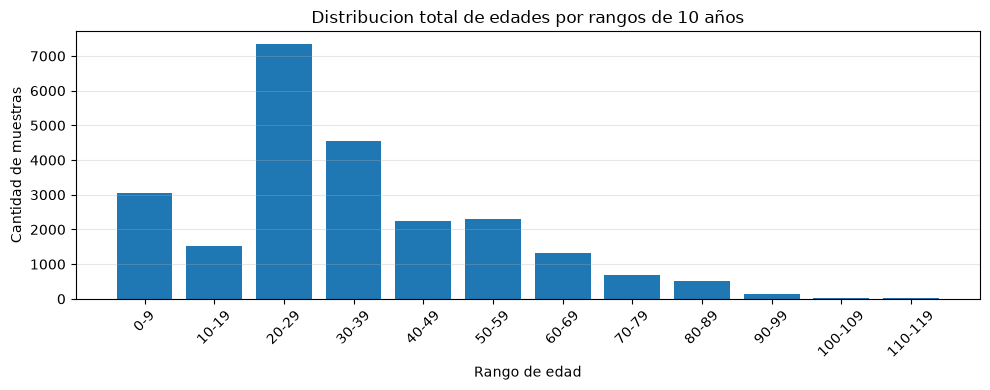

,split,age_group,n_samples
0,train,0-9,1532
1,train,10-19,774
2,train,20-29,3623
3,train,30-39,2254
4,train,40-49,1170
5,train,50-59,1186
6,train,60-69,663
7,train,70-79,317
8,train,80-89,260
9,train,90-99,51


split,test,train,validation,total
age_group,,,,
0-9,751,1532,779,3062
10-19,386,774,371,1531
20-29,1846,3623,1875,7344
30-39,1135,2254,1147,4536
40-49,547,1170,528,2245
50-59,549,1186,564,2299
60-69,342,663,311,1316
70-79,205,317,177,699
80-89,121,260,123,504


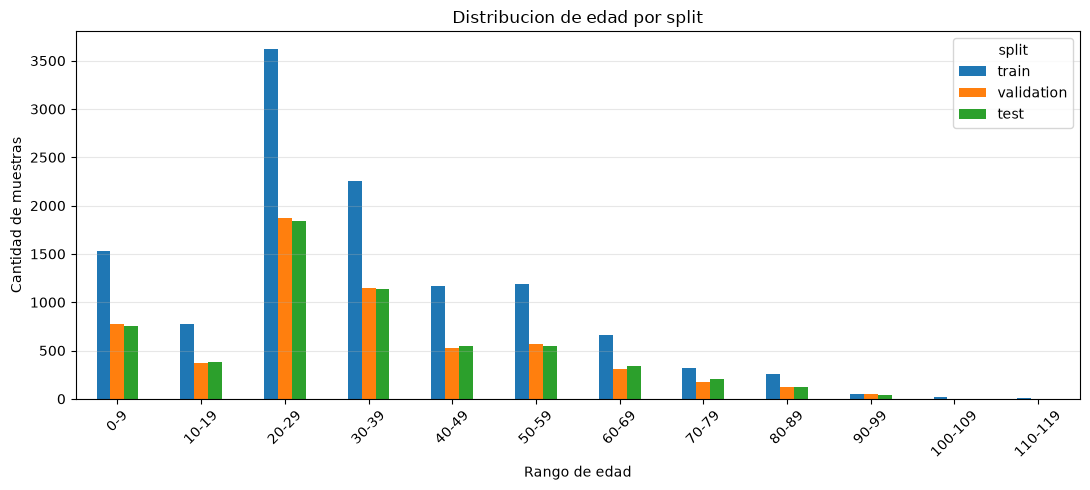

Resumen de diagnostico para Parte 6
Target minimo por rango: 2000
Rangos subrepresentados: 7
Muestras sinteticas/copias necesarias: 9781

Target minimo por rango: 3000
Rangos subrepresentados: 9
Muestras sinteticas/copias necesarias: 18237

Rangos mas subrepresentados para target 2000:


,age_group,n_samples,missing_to_2000
11,110-119,13,1987
10,100-109,19,1981
9,90-99,137,1863
8,80-89,504,1496
7,70-79,699,1301
6,60-69,1316,684
1,10-19,1531,469
0,0-9,3062,0
3,30-39,4536,0
2,20-29,7344,0


Rangos mas subrepresentados para target 3000:


,age_group,n_samples,missing_to_3000
11,110-119,13,2987
10,100-109,19,2981
9,90-99,137,2863
8,80-89,504,2496
7,70-79,699,2301
6,60-69,1316,1684
1,10-19,1531,1469
4,40-49,2245,755
5,50-59,2299,701
3,30-39,4536,0


In [4]:
# ============================================================
# PARTE 6 - DIAGNOSTICO DE BALANCE POR RANGOS DE EDAD
# ============================================================
# Objetivo:
# - Analizar la distribucion de edades del dataset.
# - Agrupar edades en intervalos de 10 años.
# - Identificar grupos subrepresentados.
# - Revisar tambien la distribucion en train/validation/test.
#
# Este bloque NO entrena modelos.
# Solo genera tablas y graficos para decidir como balancear.
# ============================================================

from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import random_split


# ============================================================
# 1. Rutas y configuracion
# ============================================================

images_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_UTK_64x64.pt"
ages_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_ages_UTK.pt"

SEED = 42

# Si por memoria queres diagnosticar con menos muestras, cambia None por un numero.
MAX_SAMPLES = None

# Minimos sugeridos por la consigna.
TARGET_OPTIONS = [2000, 3000]


# ============================================================
# 2. Cargar solo edades
# ============================================================
# Parte cubierta:
# - Analizar distribucion de edades sin cargar necesariamente imagenes.
# ============================================================

def load_ages(ages_path, max_samples=None):
    """
    Carga las edades desde el archivo .pt.

    Devuelve:
    - ages: numpy array 1D con edades.
    """

    ages = torch.load(ages_path, map_location="cpu")

    if max_samples is not None:
        ages = ages[:max_samples]

    ages = ages.to(torch.float32).view(-1).numpy()

    return ages


ages = load_ages(ages_path, max_samples=MAX_SAMPLES)

print("Cantidad total de edades:", len(ages))
print("Edad minima:", ages.min())
print("Edad maxima:", ages.max())
print("Edad media:", ages.mean())
print("Edad mediana:", np.median(ages))


# ============================================================
# 3. Crear rangos de edad de 10 años
# ============================================================
# Parte cubierta:
# - Usar age groups en intervalos de 10 años.
# ============================================================

def make_age_bins(ages, bin_width=10):
    """
    Crea bins de edad de tamaño bin_width.
    Por ejemplo:
    0-9, 10-19, 20-29, etc.
    """

    min_age = 0
    max_age = int(np.ceil(ages.max() / bin_width) * bin_width)

    bins = np.arange(min_age, max_age + bin_width, bin_width)

    labels = []
    for i in range(len(bins) - 1):
        labels.append(f"{int(bins[i])}-{int(bins[i + 1] - 1)}")

    return bins, labels


age_bins, age_labels = make_age_bins(ages, bin_width=10)

age_groups = pd.cut(
    ages,
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
    right=False
)


# ============================================================
# 4. Tabla de distribucion total
# ============================================================
# Parte cubierta:
# - Identificar rangos subrepresentados.
# ============================================================

def build_age_distribution_table(ages, age_groups):
    """
    Construye tabla de conteo por rango de edad.
    """

    df = pd.DataFrame({
        "age": ages,
        "age_group": age_groups
    })

    table = (
        df.groupby("age_group", observed=False)
        .size()
        .reset_index(name="n_samples")
    )

    table["percentage"] = 100 * table["n_samples"] / table["n_samples"].sum()

    return df, table


age_df, age_distribution = build_age_distribution_table(ages, age_groups)

display(age_distribution)


# ============================================================
# 5. Marcar rangos subrepresentados segun target
# ============================================================
# Parte cubierta:
# - Ver cuantos samples faltarian para llegar a 2000 o 3000 por rango.
# ============================================================

def add_balance_targets(age_distribution, target_values=[2000, 3000]):
    """
    Agrega columnas indicando cuantas muestras faltan
    para llegar a distintos targets.
    """

    table = age_distribution.copy()

    for target in target_values:
        table[f"missing_to_{target}"] = (target - table["n_samples"]).clip(lower=0)
        table[f"needs_aug_to_{target}"] = table[f"missing_to_{target}"] > 0

    return table


balance_table = add_balance_targets(
    age_distribution,
    target_values=TARGET_OPTIONS
)

display(balance_table)


# ============================================================
# 6. Graficar distribucion total
# ============================================================

def plot_age_distribution_table(table, title="Distribucion de edades por rango"):
    """
    Grafica cantidad de muestras por rango de edad.
    """

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.bar(table["age_group"].astype(str), table["n_samples"])
    ax.set_xlabel("Rango de edad")
    ax.set_ylabel("Cantidad de muestras")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_age_distribution_table(
    age_distribution,
    title="Distribucion total de edades por rangos de 10 años"
)


# ============================================================
# 7. Revisar distribucion por train/validation/test
# ============================================================
# Parte cubierta:
# - Confirmar si el split mantiene el desbalance.
# - Mantener el mismo split usado en partes anteriores: 50/25/25.
# ============================================================

def build_split_indices(n_samples, seed=42):
    """
    Genera indices de train/validation/test con split 50/25/25.
    """

    all_indices = list(range(n_samples))

    train_size = int(0.50 * n_samples)
    val_size = int(0.25 * n_samples)
    test_size = n_samples - train_size - val_size

    # Usamos random_split sobre indices para replicar la logica del dataset.
    train_subset, val_subset, test_subset = random_split(
        all_indices,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    return list(train_subset), list(val_subset), list(test_subset)


train_indices, val_indices, test_indices = build_split_indices(
    n_samples=len(ages),
    seed=SEED
)


def split_distribution_table(ages, indices, split_name, bins, labels):
    """
    Tabla de distribucion por rango de edad para un split.
    """

    split_ages = ages[indices]

    split_groups = pd.cut(
        split_ages,
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=False
    )

    df = pd.DataFrame({
        "age": split_ages,
        "age_group": split_groups,
        "split": split_name
    })

    table = (
        df.groupby(["split", "age_group"], observed=False)
        .size()
        .reset_index(name="n_samples")
    )

    return table


train_dist = split_distribution_table(
    ages,
    train_indices,
    "train",
    age_bins,
    age_labels
)

val_dist = split_distribution_table(
    ages,
    val_indices,
    "validation",
    age_bins,
    age_labels
)

test_dist = split_distribution_table(
    ages,
    test_indices,
    "test",
    age_bins,
    age_labels
)

split_distribution = pd.concat(
    [train_dist, val_dist, test_dist],
    ignore_index=True
)

display(split_distribution)


# ============================================================
# 8. Tabla pivot para comparar splits
# ============================================================

split_pivot = split_distribution.pivot(
    index="age_group",
    columns="split",
    values="n_samples"
).fillna(0).astype(int)

split_pivot["total"] = split_pivot.sum(axis=1)

display(split_pivot)


# ============================================================
# 9. Graficar distribucion por split
# ============================================================

def plot_split_distribution(split_pivot):
    """
    Grafica distribucion de edades por split.
    """

    plot_df = split_pivot[["train", "validation", "test"]]

    ax = plot_df.plot(
        kind="bar",
        figsize=(11, 5)
    )

    ax.set_xlabel("Rango de edad")
    ax.set_ylabel("Cantidad de muestras")
    ax.set_title("Distribucion de edad por split")
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_split_distribution(split_pivot)


# ============================================================
# 10. Resumen para decidir estrategia de balanceo
# ============================================================

print("=" * 100)
print("Resumen de diagnostico para Parte 6")
print("=" * 100)

for target in TARGET_OPTIONS:
    missing_col = f"missing_to_{target}"
    needs_col = f"needs_aug_to_{target}"

    n_underrepresented = balance_table[needs_col].sum()
    total_missing = balance_table[missing_col].sum()

    print(f"Target minimo por rango: {target}")
    print(f"Rangos subrepresentados: {n_underrepresented}")
    print(f"Muestras sinteticas/copias necesarias: {total_missing}")
    print()

print("Rangos mas subrepresentados para target 2000:")
display(
    balance_table.sort_values("missing_to_2000", ascending=False)
    [["age_group", "n_samples", "missing_to_2000"]]
    .head(10)
)

print("Rangos mas subrepresentados para target 3000:")
display(
    balance_table.sort_values("missing_to_3000", ascending=False)
    [["age_group", "n_samples", "missing_to_3000"]]
    .head(10)
)



In [5]:
# ============================================================
# PARTE 6 - DATA AUGMENTATION PARA BALANCEAR RANGOS DE EDAD
# ============================================================
# Objetivo de la consigna:
# - Analizar grupos de edad subrepresentados.
# - Crear un dataset extendido para que cada grupo tenga al menos 2000 muestras.
# - Generar diversidad aplicando augmentation en __getitem__.
# - Reentrenar la CNN y verificar si mejora el sesgo hacia edades frecuentes.
#
# Estrategia eficiente en memoria:
# - NO duplicamos imagenes.
# - Solo duplicamos indices.
# - Las copias virtuales se transforman aleatoriamente en __getitem__.
# - Validation y test NO se balancean ni se augmentan.
# ============================================================

import gc
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import pandas as pd

try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

from pytorch_lightning.loggers import MLFlowLogger
from pytorch_lightning.callbacks import EarlyStopping

import mlflow

import torchvision.transforms.v2 as v2


# ============================================================
# 1. Configuración general
# ============================================================

images_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_UTK_64x64.pt"
ages_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_ages_UTK.pt"

TRACKING_URI = "sqlite:///mlruns/mlflow.db"

# Uso el mismo experimento donde venis comparando.
EXPERIMENT = "UTKFace_Age_Regression_Part4_Regularization_v3"

Path("mlruns").mkdir(exist_ok=True)
Path("predictions_part6").mkdir(exist_ok=True)
Path("age_ranges_part6").mkdir(exist_ok=True)
Path("balance_tables_part6").mkdir(exist_ok=True)

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT)

SEED = 42
pl.seed_everything(SEED, workers=True)

batch_size = 16
max_epochs = 50
learning_rate = 1e-3

# Por memoria, usamos target 2000 como decidiste.
TARGET_PER_AGE_GROUP = 2000
BIN_WIDTH = 10

# Si el kernel vuelve a quedar justo, podes usar un subconjunto.
# Pero para esta consigna conviene None si ya te corrio antes.
MAX_SAMPLES = None

accelerator = "auto"
devices = "auto"
precision = "16-mixed" if torch.cuda.is_available() else "32-true"

print("CUDA disponible:", torch.cuda.is_available())
print("Precision:", precision)
print("Target por rango de edad:", TARGET_PER_AGE_GROUP)


# ============================================================
# 2. Transformaciones para generar diversidad
# ============================================================
# Parte de la consigna cubierta:
# - Random Horizontal Flip.
# - Rotation.
# - Brightness / Contrast.
# - Random Resized Crop.
#
# Usamos valores moderados para no crear rostros poco realistas.
# ============================================================

balance_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=12),
    v2.ColorJitter(brightness=0.12, contrast=0.12),
    v2.RandomResizedCrop(size=(64, 64), scale=(0.88, 1.0)),
])


# ============================================================
# 3. Carga de tensores
# ============================================================
# Parte cubierta:
# - Cargar imagenes y edades.
# - Escalar pixeles a [0, 1].
# ============================================================

def load_tensors(images_path, ages_path, max_samples=None):
    """
    Carga tensores preprocesados desde .pt.
    """

    images = torch.load(images_path, map_location="cpu")
    ages = torch.load(ages_path, map_location="cpu")

    if max_samples is not None:
        images = images[:max_samples]
        ages = ages[:max_samples]

    images = images.to(torch.float32)

    if images.max() > 1:
        images = images / 255.0

    ages = ages.to(torch.float32)

    if ages.ndim == 1:
        ages = ages.view(-1, 1)

    return images, ages


images, ages = load_tensors(
    images_path=images_path,
    ages_path=ages_path,
    max_samples=MAX_SAMPLES
)

print("Imagenes:", images.shape)
print("Edades:", ages.shape)


# ============================================================
# 4. Dataset base y dataset balanceado
# ============================================================
# Parte cubierta:
# - Modificar __getitem__ para aplicar transforms aleatorias.
# - El dataset balanceado usa indices, no copias de imagenes.
# ============================================================

class UTKFaceIndexedDataset(Dataset):
    """
    Dataset indexado para UTKFace.

    Recibe:
    - images: tensor de imagenes
    - ages: tensor de edades
    - indices: lista de indices a usar
    - augmented_flags: indica si cada item debe recibir augmentation

    Esto permite:
    - mantener validation/test sin augmentation
    - aplicar augmentation solo a copias virtuales o a train
    """

    def __init__(self, images, ages, indices, augmented_flags=None, transform=None):
        self.images = images
        self.ages = ages
        self.indices = list(indices)

        if augmented_flags is None:
            augmented_flags = [False] * len(self.indices)

        self.augmented_flags = list(augmented_flags)
        self.transform = transform

    def __getitem__(self, item):
        original_index = self.indices[item]

        image = self.images[original_index]
        age = self.ages[original_index]

        # Las muestras marcadas como augmentadas reciben transform aleatoria.
        if self.augmented_flags[item] and self.transform is not None:
            image = self.transform(image)

        return image.float(), age.float()

    def __len__(self):
        return len(self.indices)


# ============================================================
# 5. Crear bins de edad y balancear SOLO train
# ============================================================
# Parte cubierta:
# - Agrupar edades en intervalos de 10 años.
# - Identificar grupos subrepresentados.
# - Generar indices adicionales hasta llegar a target=2000.
# ============================================================

def make_age_bins(ages_np, bin_width=10):
    """
    Crea bins 0-9, 10-19, 20-29, ...
    """

    min_age = 0
    max_age = int(np.ceil(ages_np.max() / bin_width) * bin_width)

    bins = np.arange(min_age, max_age + bin_width, bin_width)

    labels = [
        f"{int(bins[i])}-{int(bins[i + 1] - 1)}"
        for i in range(len(bins) - 1)
    ]

    return bins, labels


def build_split_indices(n_samples, seed=42):
    """
    Genera split 50/25/25 reproducible.
    """

    all_indices = list(range(n_samples))

    train_size = int(0.50 * n_samples)
    val_size = int(0.25 * n_samples)
    test_size = n_samples - train_size - val_size

    train_subset, val_subset, test_subset = random_split(
        all_indices,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    return list(train_subset), list(val_subset), list(test_subset)


def build_balanced_train_indices(
    train_indices,
    ages,
    target_per_group=2000,
    bin_width=10,
    seed=42
):
    """
    Balancea el train set por rangos de edad.

    Importante:
    - No duplica imagenes.
    - Agrega indices repetidos para grupos subrepresentados.
    - Marca esos indices agregados como augmented=True.
    """

    rng = np.random.default_rng(seed)

    ages_np = ages.view(-1).cpu().numpy()
    bins, labels = make_age_bins(ages_np, bin_width=bin_width)

    train_ages = ages_np[train_indices]

    train_groups = pd.cut(
        train_ages,
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=False
    )

    train_df = pd.DataFrame({
        "index": train_indices,
        "age": train_ages,
        "age_group": train_groups
    })

    original_indices = []
    original_flags = []

    added_indices = []
    added_flags = []

    balance_rows = []

    for label in labels:
        group_df = train_df[train_df["age_group"] == label]
        group_indices = group_df["index"].to_numpy()

        n_original = len(group_indices)
        n_to_add = max(target_per_group - n_original, 0)

        if n_original > 0 and n_to_add > 0:
            sampled = rng.choice(group_indices, size=n_to_add, replace=True)
            added_indices.extend(sampled.tolist())
            added_flags.extend([True] * n_to_add)

        balance_rows.append({
            "age_group": label,
            "original_train_samples": n_original,
            "added_augmented_samples": n_to_add,
            "final_train_samples": n_original + n_to_add
        })

    original_indices = list(train_indices)
    original_flags = [False] * len(original_indices)

    balanced_indices = original_indices + added_indices
    augmented_flags = original_flags + added_flags

    balance_table = pd.DataFrame(balance_rows)

    return balanced_indices, augmented_flags, balance_table


train_indices, val_indices, test_indices = build_split_indices(
    n_samples=len(ages),
    seed=SEED
)

balanced_train_indices, balanced_train_flags, balance_table = build_balanced_train_indices(
    train_indices=train_indices,
    ages=ages,
    target_per_group=TARGET_PER_AGE_GROUP,
    bin_width=BIN_WIDTH,
    seed=SEED
)

display(balance_table)

balance_table_path = "balance_tables_part6/P6_balance_table_target2000.csv"
balance_table.to_csv(balance_table_path, index=False)

print("Train original:", len(train_indices))
print("Train balanceado:", len(balanced_train_indices))
print("Muestras virtuales agregadas:", sum(balanced_train_flags))


# ============================================================
# 6. Crear DataLoaders
# ============================================================
# Parte cubierta:
# - Train balanceado con augmentation en copias virtuales.
# - Validation y test sin balanceo ni augmentation.
# ============================================================

train_dataset = UTKFaceIndexedDataset(
    images=images,
    ages=ages,
    indices=balanced_train_indices,
    augmented_flags=balanced_train_flags,
    transform=balance_transform
)

val_dataset = UTKFaceIndexedDataset(
    images=images,
    ages=ages,
    indices=val_indices,
    augmented_flags=None,
    transform=None
)

test_dataset = UTKFaceIndexedDataset(
    images=images,
    ages=ages,
    indices=test_indices,
    augmented_flags=None,
    transform=None
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

sample_images, _ = next(iter(train_loader))
input_channels = sample_images.shape[1]

print("Shape batch train:", sample_images.shape)
print("Canales:", input_channels)


# ============================================================
# 7. Modelo CNN
# ============================================================
# Usamos la mejor estrategia previa: BatchNorm.
# Agregamos EarlyStopping exigente para evitar entrenar de mas.
# ============================================================

class AgeCNNBatchNorm(nn.Module):
    """
    CNN con BatchNorm para regresion de edad.
    """

    def __init__(self, input_channels=3):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


class LitAgeCNN(pl.LightningModule):
    """
    LightningModule para CNN de regresion.
    """

    def __init__(self, model, learning_rate=1e-3, target_per_age_group=2000):
        super().__init__()

        self.save_hyperparameters(ignore=["model"])

        self.model = model
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        images, ages = batch

        ages = ages.float()
        if ages.ndim == 1:
            ages = ages.view(-1, 1)

        preds = self(images)
        loss = self.loss_fn(preds, ages)

        return loss, preds, ages

    def training_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "train_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "val_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def test_step(self, batch, batch_idx):
        loss, preds, ages = self._shared_step(batch)

        self.log(
            "test_loss",
            loss,
            on_epoch=True,
            on_step=False,
            prog_bar=True
        )

        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.learning_rate
        )


# ============================================================
# 8. Evaluacion y guardado de artefactos
# ============================================================

def evaluate_regression_model(model, dataloader, device=None):
    """
    Calcula MSE, MAE y guarda predicciones.
    """

    if device is None:
        device = next(model.parameters()).device

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_images, batch_ages in dataloader:
            batch_images = batch_images.to(device)
            batch_ages = batch_ages.to(device).float()

            if batch_ages.ndim == 1:
                batch_ages = batch_ages.view(-1, 1)

            preds = model(batch_images)

            all_preds.append(preds.detach().cpu())
            all_targets.append(batch_ages.detach().cpu())

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    mse = F.mse_loss(all_preds, all_targets).item()
    mae = F.l1_loss(all_preds, all_targets).item()

    return {
        "mse": mse,
        "mae": mae,
        "preds": all_preds.numpy().flatten(),
        "targets": all_targets.numpy().flatten()
    }


def save_predictions_csv(metrics, output_path):
    """
    Guarda predicciones de test.
    """

    df = pd.DataFrame({
        "y_true": metrics["targets"],
        "y_pred": metrics["preds"]
    })

    df["abs_error"] = np.abs(df["y_pred"] - df["y_true"])
    df.to_csv(output_path, index=False)

    return output_path


def compute_age_range_errors(predictions_csv, output_path):
    """
    Calcula MAE/MSE por rango de edad.
    """

    df = pd.read_csv(predictions_csv)

    age_bins = [
        (0, 9, "0-9"),
        (10, 19, "10-19"),
        (20, 29, "20-29"),
        (30, 39, "30-39"),
        (40, 49, "40-49"),
        (50, 59, "50-59"),
        (60, 69, "60-69"),
        (70, 79, "70-79"),
        (80, 89, "80-89"),
        (90, 99, "90-99"),
        (100, 109, "100-109"),
        (110, 119, "110-119"),
    ]

    rows = []

    for min_age, max_age, label in age_bins:
        mask = (df["y_true"] >= min_age) & (df["y_true"] <= max_age)
        group = df[mask]

        if len(group) > 0:
            rows.append({
                "age_group": label,
                "n_samples": len(group),
                "mae": group["abs_error"].mean(),
                "mse": np.mean((group["y_pred"] - group["y_true"]) ** 2)
            })

    range_df = pd.DataFrame(rows)
    range_df.to_csv(output_path, index=False)

    return output_path


# ============================================================
# 9. Entrenamiento
# ============================================================

RUN_NAME = "P6_BalancedAug_Target2000_BatchNorm"

base_model = AgeCNNBatchNorm(input_channels=input_channels)

lit_model = LitAgeCNN(
    model=base_model,
    learning_rate=learning_rate,
    target_per_age_group=TARGET_PER_AGE_GROUP
)

mlf_logger = MLFlowLogger(
    experiment_name=EXPERIMENT,
    tracking_uri=TRACKING_URI,
    run_name=RUN_NAME
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    min_delta=0.5,
    mode="min",
    verbose=True
)

trainer = pl.Trainer(
    max_epochs=max_epochs,
    accelerator=accelerator,
    devices=devices,
    precision=precision,
    deterministic=True,
    log_every_n_steps=25,
    logger=mlf_logger,
    callbacks=[early_stopping],
    enable_checkpointing=False
)

trainer.fit(
    lit_model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

trainer.test(
    lit_model,
    dataloaders=test_loader
)


# ============================================================
# 10. Metricas finales y artefactos
# ============================================================

train_metrics = evaluate_regression_model(lit_model, train_loader)
val_metrics = evaluate_regression_model(lit_model, val_loader)
test_metrics = evaluate_regression_model(lit_model, test_loader)

run_id = mlf_logger.run_id

mlf_logger.experiment.log_metric(run_id, "train_mse_final", train_metrics["mse"])
mlf_logger.experiment.log_metric(run_id, "train_mae_final", train_metrics["mae"])
mlf_logger.experiment.log_metric(run_id, "val_mse_final", val_metrics["mse"])
mlf_logger.experiment.log_metric(run_id, "val_mae_final", val_metrics["mae"])
mlf_logger.experiment.log_metric(run_id, "test_mse_final", test_metrics["mse"])
mlf_logger.experiment.log_metric(run_id, "test_mae_final", test_metrics["mae"])

pred_path = "predictions_part6/P6_BalancedAug_Target2000_BatchNorm_test_predictions.csv"
range_path = "age_ranges_part6/P6_BalancedAug_Target2000_BatchNorm_age_range_errors.csv"

save_predictions_csv(test_metrics, pred_path)
compute_age_range_errors(pred_path, range_path)

mlf_logger.experiment.log_artifact(run_id, pred_path, artifact_path="predictions")
mlf_logger.experiment.log_artifact(run_id, range_path, artifact_path="age_ranges")
mlf_logger.experiment.log_artifact(run_id, balance_table_path, artifact_path="balance_tables")

print("=" * 100)
print("Run finalizado:", RUN_NAME)
print("run_id:", run_id)
print("Train MAE:", train_metrics["mae"])
print("Val MAE:", val_metrics["mae"])
print("Test MAE:", test_metrics["mae"])
print("Test MSE:", test_metrics["mse"])
print("=" * 100)


# ============================================================
# 11. Limpieza de memoria
# ============================================================

del base_model
del lit_model
del trainer
del train_metrics
del val_metrics
del test_metrics

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Seed set to 42


CUDA disponible: False
Precision: 32-true
Target por rango de edad: 2000
Imagenes: torch.Size([23705, 3, 64, 64])
Edades: torch.Size([23705, 1])


,age_group,original_train_samples,added_augmented_samples,final_train_samples
0,0-9,1532,468,2000
1,10-19,774,1226,2000
2,20-29,3623,0,3623
3,30-39,2254,0,2254
4,40-49,1170,830,2000
5,50-59,1186,814,2000
6,60-69,663,1337,2000
7,70-79,317,1683,2000
8,80-89,260,1740,2000
9,90-99,51,1949,2000


Train original: 11852
Train balanceado: 25877
Muestras virtuales agregadas: 14025
Shape batch train: torch.Size([16, 3, 64, 64])
Canales: 3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type            | Params | Mode  | FLOPs
------------------------------------------------------------
0 | model   | AgeCNNBatchNorm | 2.1 M  | train | 0    
1 | loss_fn | MSELoss         | 0      | train | 0    
------------------------------------------------------------
2.1 M     Trainable params
0         Non-trainable params
2.1 M     Total params
8.468     Total estimated model params size (MB)
16        Modules in train mode
0         Modules in eval mode
0         Total Flops


...

Epoch 7: 100%|██████████| 1618/1618 [02:28<00:00, 10.93it/s, v_num=568f, val_loss=85.70, train_loss=80.30]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 8: 100%|██████████| 1618/1618 [02:28<00:00, 10.93it/s, v_num=568f, val_loss=93.00, train_loss=73.00]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 8: 100%|██████████| 1618/1618 [02:41<00:00, 10.01it/s, v_num=568f, val_loss=96.70, train_loss=73.00]

Monitored metric val_loss did not improve in the last 2 records. Best score: 85.727. Signaling Trainer to stop.


Epoch 8: 100%|██████████| 1618/1618 [02:41<00:00, 10.01it/s, v_num=568f, val_loss=96.70, train_loss=69.60]


C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 371/371 [00:12<00:00, 29.26it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           102.26641845703125
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Run finalizado: P6_BalancedAug_Target2000_BatchNorm
run_id: b9b3e236388f4599a6346b042669568f
Train MAE: 7.096007823944092
Val MAE: 7.453035354614258
Test MAE: 7.643510818481445
Test MSE: 102.26647186279297


,run_id,tags.mlflow.runName,status,metrics.train_mae_final,metrics.val_mae_final,metrics.test_mae_final,metrics.train_mse_final,metrics.val_mse_final,metrics.test_mse_final
0,b9b3e236388f4599a6346b042669568f,P6_BalancedAug_Target2000_BatchNorm,FINISHED,7.096008,7.453035,7.643511,81.846252,96.715668,102.266472
7,bcd08ea1e30a46a08b6c5fc81e05c992,P4_v3_CNN_BatchNorm,FINISHED,1.568974,6.714406,6.955759,4.807241,87.263489,93.324844


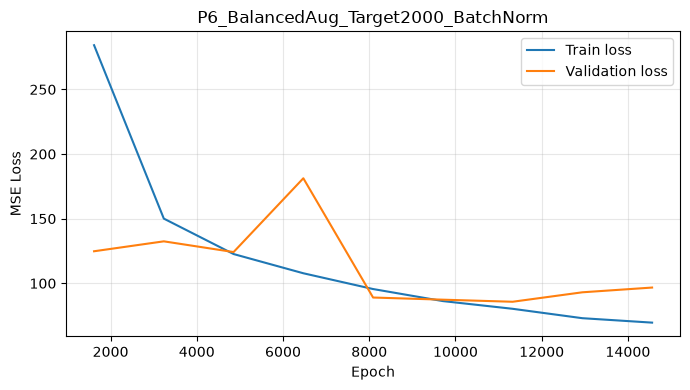

Figura guardada: figures_part6/loss_P6_BalancedAug_Target2000_BatchNorm.png


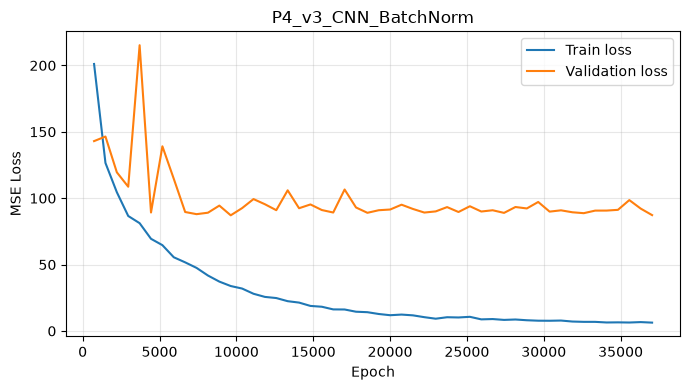

Figura guardada: figures_part6/loss_P4_v3_CNN_BatchNorm.png


,run_name,run_id,train_mae,val_mae,test_mae,train_mse,val_mse,test_mse
7,P4_v3_CNN_BatchNorm,bcd08ea1e30a46a08b6c5fc81e05c992,1.568974,6.714406,6.955759,4.807241,87.263489,93.324844
0,P6_BalancedAug_Target2000_BatchNorm,b9b3e236388f4599a6346b042669568f,7.096008,7.453035,7.643511,81.846252,96.715668,102.266472


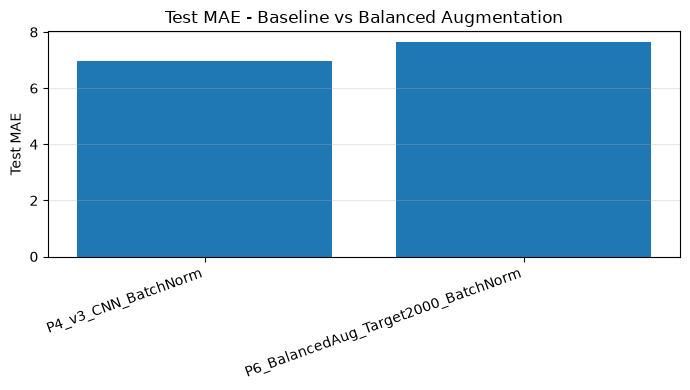

Figura guardada: figures_part6/test_mae_baseline_vs_balanced.png


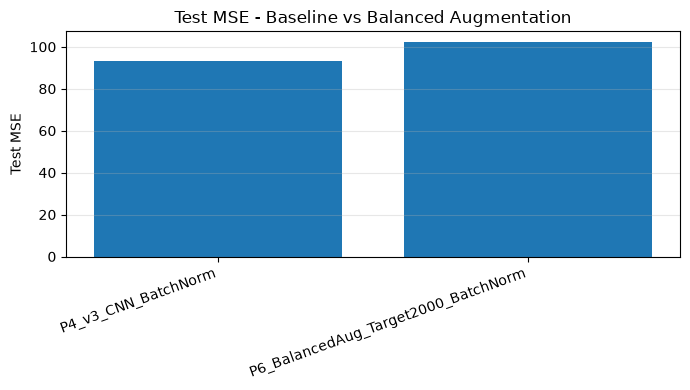

Figura guardada: figures_part6/test_mse_baseline_vs_balanced.png


,age_group,original_train_samples,added_augmented_samples,final_train_samples
0,0-9,1532,468,2000
1,10-19,774,1226,2000
2,20-29,3623,0,3623
3,30-39,2254,0,2254
4,40-49,1170,830,2000
5,50-59,1186,814,2000
6,60-69,663,1337,2000
7,70-79,317,1683,2000
8,80-89,260,1740,2000
9,90-99,51,1949,2000


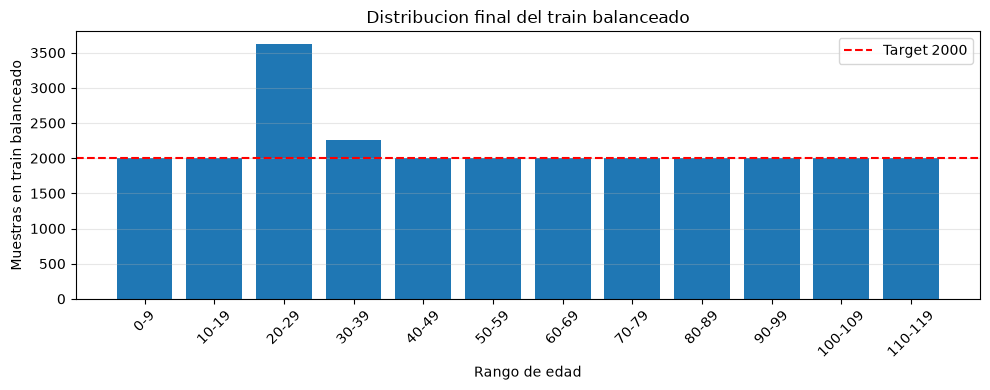

Figura guardada: figures_part6/balanced_train_distribution.png


,y_true,y_pred,abs_error
0,18.0,23.191957,5.191958
1,68.0,64.000786,3.999214
2,6.0,13.850100,7.850100
3,27.0,19.854502,7.145498
4,28.0,38.827812,10.827812


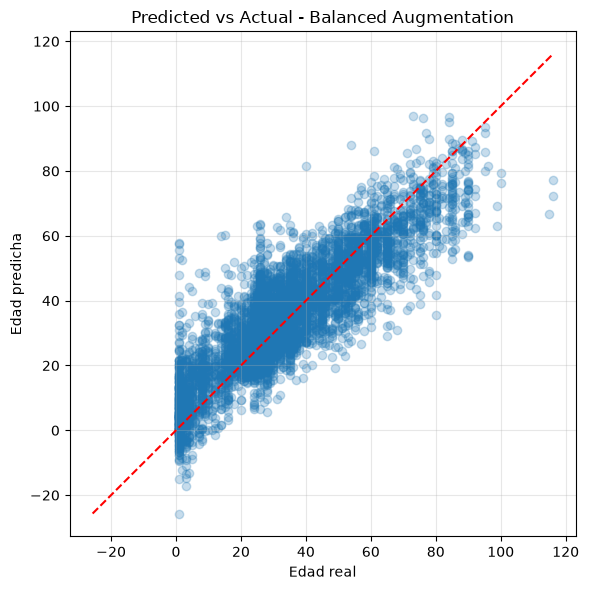

Figura guardada: figures_part6/predicted_vs_actual_balanced.png


,age_group,n_samples,mae,mse
0,0-9,751,8.841298,144.798560
1,10-19,386,8.876876,131.957736
2,20-29,1846,6.684497,79.614234
3,30-39,1135,6.509054,67.614476
4,40-49,547,6.874209,74.142006
5,50-59,549,7.440806,91.655626
6,60-69,342,8.646668,119.267190
7,70-79,205,10.594216,174.527868
8,80-89,121,13.711762,267.764805
9,90-99,40,17.533005,404.583019


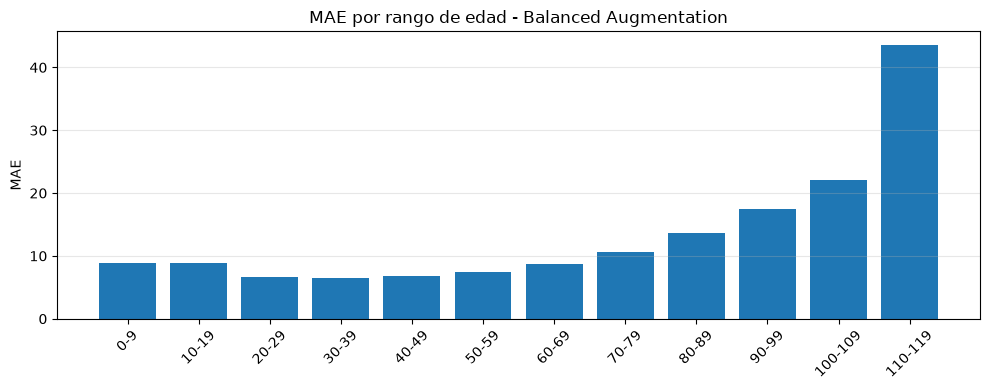

Figura guardada: figures_part6/mae_by_age_range_balanced.png
Resumen para responder la consigna
Baseline: P4_v3_CNN_BatchNorm
Baseline Test MAE: 6.956
Baseline Test MSE: 93.325

Balanced augmentation: P6_BalancedAug_Target2000_BatchNorm
Balanced Test MAE: 7.644
Balanced Test MSE: 102.266

El balanceo con augmentation no mejoro el MAE global en test.

Puntos cubiertos:
- Se identificaron rangos subrepresentados en intervalos de 10 años.
- Se extendio el train set hasta un minimo de 2000 muestras por rango.
- Las copias virtuales se augmentaron en __getitem__ para generar diversidad.
- Se reentreno la CNN BatchNorm con el train balanceado.
- Se comparo MSE/MAE contra el mejor modelo previo.
- Se analizo predicted vs actual.
- Se analizo MAE por rango de edad.

Discusion sugerida:
- El objetivo principal del balanceo no es necesariamente bajar el MAE global, sino reducir sesgos por edad.
- Si el MAE global empeora pero mejora en rangos mayores, el balanceo puede haber corregido parcialmen

In [6]:
# ============================================================
# PARTE 6 - VISUALIZACION Y RESPUESTA DESDE MLFLOW
# ============================================================
# Objetivo:
# - Comparar el modelo balanceado contra el mejor modelo previo:
#   P4_v3_CNN_BatchNorm.
# - Analizar si el balanceo mejora grupos subrepresentados.
# - Mostrar:
#   - curvas train/val
#   - MSE/MAE finales
#   - predicted vs actual
#   - MAE por rango de edad
#   - tabla de balance aplicado
# ============================================================

from pathlib import Path

import mlflow
from mlflow.tracking import MlflowClient

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Configuracion
# ============================================================

TRACKING_URI = "sqlite:///mlruns/mlflow.db"
EXPERIMENT = "UTKFace_Age_Regression_Part4_Regularization_v3"

mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient(tracking_uri=TRACKING_URI)

Path("figures_part6").mkdir(exist_ok=True)

BASELINE_RUN_NAME = "P4_v3_CNN_BatchNorm"
BALANCED_RUN_NAME = "P6_BalancedAug_Target2000_BatchNorm"


# ============================================================
# 2. Recuperar runs relevantes
# ============================================================

def get_runs_by_name(experiment_name, run_names):
    """
    Recupera runs por nombre desde MLflow.
    Si hay varios con el mismo nombre, usa el mas reciente.
    """

    experiment = mlflow.get_experiment_by_name(experiment_name)

    if experiment is None:
        raise ValueError(f"No existe el experimento: {experiment_name}")

    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        output_format="pandas"
    )

    selected = runs[runs["tags.mlflow.runName"].isin(run_names)].copy()

    selected = selected.sort_values("start_time", ascending=False)
    selected = selected.drop_duplicates(subset=["tags.mlflow.runName"], keep="first")

    return selected


runs_df = get_runs_by_name(
    EXPERIMENT,
    [BASELINE_RUN_NAME, BALANCED_RUN_NAME]
)

display_cols = [
    "run_id",
    "tags.mlflow.runName",
    "status",
    "metrics.train_mae_final",
    "metrics.val_mae_final",
    "metrics.test_mae_final",
    "metrics.train_mse_final",
    "metrics.val_mse_final",
    "metrics.test_mse_final"
]

display(runs_df[display_cols])


# ============================================================
# 3. Curvas train_loss vs val_loss
# ============================================================

def get_metric_history(run_id, metric_name):
    history = client.get_metric_history(run_id, metric_name)
    steps = [m.step for m in history]
    values = [m.value for m in history]
    return steps, values


def plot_loss_curves_for_runs(runs_df):
    """
    Grafica curvas train/val para baseline y modelo balanceado.
    """

    for _, row in runs_df.iterrows():
        run_id = row["run_id"]
        run_name = row["tags.mlflow.runName"]

        train_steps, train_loss = get_metric_history(run_id, "train_loss")
        val_steps, val_loss = get_metric_history(run_id, "val_loss")

        fig, ax = plt.subplots(figsize=(7, 4))

        ax.plot(train_steps, train_loss, label="Train loss")
        ax.plot(val_steps, val_loss, label="Validation loss")

        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE Loss")
        ax.set_title(run_name)
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()

        filename = f"figures_part6/loss_{run_name}.png"
        plt.savefig(filename, dpi=120)
        plt.show()
        plt.close(fig)

        print("Figura guardada:", filename)


plot_loss_curves_for_runs(runs_df)


# ============================================================
# 4. Tabla comparativa MSE/MAE
# ============================================================

comparison_table = pd.DataFrame({
    "run_name": runs_df["tags.mlflow.runName"],
    "run_id": runs_df["run_id"],
    "train_mae": runs_df["metrics.train_mae_final"],
    "val_mae": runs_df["metrics.val_mae_final"],
    "test_mae": runs_df["metrics.test_mae_final"],
    "train_mse": runs_df["metrics.train_mse_final"],
    "val_mse": runs_df["metrics.val_mse_final"],
    "test_mse": runs_df["metrics.test_mse_final"],
}).sort_values("test_mae", ascending=True)

display(comparison_table)


def plot_metric_bar(table, metric_name, title, ylabel, filename):
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(table["run_name"], table[metric_name])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    output_path = f"figures_part6/{filename}"
    plt.savefig(output_path, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", output_path)


plot_metric_bar(
    comparison_table,
    "test_mae",
    "Test MAE - Baseline vs Balanced Augmentation",
    "Test MAE",
    "test_mae_baseline_vs_balanced.png"
)

plot_metric_bar(
    comparison_table,
    "test_mse",
    "Test MSE - Baseline vs Balanced Augmentation",
    "Test MSE",
    "test_mse_baseline_vs_balanced.png"
)


# ============================================================
# 5. Descargar artefactos CSV
# ============================================================

def find_csv_artifact(run_id, artifact_folder):
    artifacts = client.list_artifacts(run_id, artifact_folder)

    for artifact in artifacts:
        if artifact.path.endswith(".csv"):
            return artifact.path

    return None


def download_csv_artifact(run_id, artifact_folder):
    artifact_path = find_csv_artifact(run_id, artifact_folder)

    if artifact_path is None:
        return None

    local_path = client.download_artifacts(run_id, artifact_path)
    return pd.read_csv(local_path)


balanced_row = runs_df[runs_df["tags.mlflow.runName"] == BALANCED_RUN_NAME].iloc[0]
balanced_run_id = balanced_row["run_id"]

balanced_predictions = download_csv_artifact(
    balanced_run_id,
    "predictions"
)

balanced_age_ranges = download_csv_artifact(
    balanced_run_id,
    "age_ranges"
)

balance_table = download_csv_artifact(
    balanced_run_id,
    "balance_tables"
)


# ============================================================
# 6. Tabla de balance aplicado
# ============================================================

if balance_table is not None:
    display(balance_table)

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.bar(
        balance_table["age_group"],
        balance_table["final_train_samples"]
    )

    ax.axhline(2000, color="red", linestyle="--", label="Target 2000")
    ax.set_xlabel("Rango de edad")
    ax.set_ylabel("Muestras en train balanceado")
    ax.set_title("Distribucion final del train balanceado")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()

    filename = "figures_part6/balanced_train_distribution.png"
    plt.savefig(filename, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", filename)


# ============================================================
# 7. Predicted vs actual
# ============================================================

if balanced_predictions is not None:
    display(balanced_predictions.head())

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        balanced_predictions["y_true"],
        balanced_predictions["y_pred"],
        alpha=0.25
    )

    min_age = min(balanced_predictions["y_true"].min(), balanced_predictions["y_pred"].min())
    max_age = max(balanced_predictions["y_true"].max(), balanced_predictions["y_pred"].max())

    ax.plot([min_age, max_age], [min_age, max_age], color="red", linestyle="--")

    ax.set_xlabel("Edad real")
    ax.set_ylabel("Edad predicha")
    ax.set_title("Predicted vs Actual - Balanced Augmentation")
    ax.grid(alpha=0.3)

    plt.tight_layout()

    filename = "figures_part6/predicted_vs_actual_balanced.png"
    plt.savefig(filename, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", filename)


# ============================================================
# 8. MAE por rango de edad
# ============================================================

if balanced_age_ranges is not None:
    display(balanced_age_ranges)

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.bar(
        balanced_age_ranges["age_group"],
        balanced_age_ranges["mae"]
    )

    ax.set_ylabel("MAE")
    ax.set_title("MAE por rango de edad - Balanced Augmentation")
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()

    filename = "figures_part6/mae_by_age_range_balanced.png"
    plt.savefig(filename, dpi=120)
    plt.show()
    plt.close(fig)

    print("Figura guardada:", filename)


# ============================================================
# 9. Resumen interpretativo
# ============================================================

baseline_row = runs_df[runs_df["tags.mlflow.runName"] == BASELINE_RUN_NAME].iloc[0]

baseline_mae = baseline_row["metrics.test_mae_final"]
balanced_mae = balanced_row["metrics.test_mae_final"]

baseline_mse = baseline_row["metrics.test_mse_final"]
balanced_mse = balanced_row["metrics.test_mse_final"]

print("=" * 100)
print("Resumen para responder la consigna")
print("=" * 100)

print(f"Baseline: {BASELINE_RUN_NAME}")
print(f"Baseline Test MAE: {baseline_mae:.3f}")
print(f"Baseline Test MSE: {baseline_mse:.3f}")

print()
print(f"Balanced augmentation: {BALANCED_RUN_NAME}")
print(f"Balanced Test MAE: {balanced_mae:.3f}")
print(f"Balanced Test MSE: {balanced_mse:.3f}")

print()
if balanced_mae < baseline_mae:
    print("El balanceo con augmentation mejoro el MAE global en test.")
else:
    print("El balanceo con augmentation no mejoro el MAE global en test.")

print()
print("Puntos cubiertos:")
print("- Se identificaron rangos subrepresentados en intervalos de 10 años.")
print("- Se extendio el train set hasta un minimo de 2000 muestras por rango.")
print("- Las copias virtuales se augmentaron en __getitem__ para generar diversidad.")
print("- Se reentreno la CNN BatchNorm con el train balanceado.")
print("- Se comparo MSE/MAE contra el mejor modelo previo.")
print("- Se analizo predicted vs actual.")
print("- Se analizo MAE por rango de edad.")

print()
print("Discusion sugerida:")
print("- El objetivo principal del balanceo no es necesariamente bajar el MAE global, sino reducir sesgos por edad.")
print("- Si el MAE global empeora pero mejora en rangos mayores, el balanceo puede haber corregido parcialmente el sesgo.")
print("- Los rangos 90+, 100+ y 110+ tienen muy pocas muestras reales; aunque se creen copias augmentadas, la diversidad real sigue siendo limitada.")
print("- Por eso, un target moderado como 2000 es mas razonable que 3000 en este entorno.")
print("=" * 100)

## 6. Transfer Learning with Pretrained Models

In this final part of the lab, you will explore **transfer learning**, a powerful technique that uses pre-trained models to solve new tasks more efficiently. The idea is to start from a deep neural network that has already been trained on a large dataset (such as ImageNet), and adapt it to your current problem—in this case, **predicting age from facial images**.

You will work with the **ResNet18** architecture, available through `torchvision.models`. ResNet18 is a CNN composed of residual blocks and approximately 11 million parameters. It was originally trained on the **ImageNet** dataset, which contains over 1 million images across 1000 categories. Thanks to its learned filters and representations, ResNet18 can serve as a powerful **feature extractor** for a wide range of visual tasks, including regression.

Adapt ResNet18 to perform age regression and compare its performance with the models implemented in previous parts.

Specifically, you will:

- **Load ResNet18 pre-trained on ImageNet** using `torchvision.models.resnet18(pretrained=True)`.

- **Modify the last layer** of the model to output a single value (age), instead of 1000 classification logits. The original final layer is:
  ```python
  model.fc = nn.Linear(512, 1000)
  ```
  You will replace it with:
  ```python
  model.fc = nn.Linear(512, 1)
  ```

- **Data transformation**: ResNet18 expects input images with shape 3×224×224 (RGB format) and normalized pixel values, ensure that your images are correctly resized and normalized to match the format expected by the model. You can use this transformation directly when preparing your dataset:
```python
 transforms = [
    v2.Resize((IMG_SIZE_resnet, IMG_SIZE_resnet)),  # Resize to 224x224 for ResNet
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats
]  
```

- **Try two training strategies**:
  1. **Feature extraction (freeze all convolutional layers)**: This approach uses the learned representations from ImageNet as fixed features, and only updates the final regression head.
     To freeze the backbone, use:
     ```python
     for param in self.feature_extractor.parameters():
                param.requires_grad = False
     ```
  2. **Fine-tuning**: After training the regression head for a few epochs, you can **unfreeze the full network** and train all layers together with a lower learning rate, adapting all parameters to the age regression task.

As before, you will wrap your model in a **PyTorch LightningModule**, train it using `MSELoss`, and evaluate its performance using **MAE and MSE**. You can try to use any regularization strategy and data augmentation to improve the model performance.

Finally, compare your ResNet18 runs to previous models and analyze whether transfer learning improves generalization.

Note: ResNet18 expects input images with shape 3×224×224 (RGB format) and normalized pixel values. Fortunately, the pretrained ResNet models from torchvision.models come with a predefined preprocessing pipeline (weights.transforms()), which ensures that your images are correctly resized and normalized to match the format expected by the model. You can use this transformation directly when preparing your dataset.

In [3]:
# ==============================================================================
# BLOQUE 1: CARGA DE DATASET .PT Y CONFIGURACIÓN DE DATALOADERS
# ==============================================================================
import gc
import torch
from torch.utils.data import Dataset, random_split, DataLoader
import torchvision.transforms.v2 as v2

# 1. Rutas exactas del usuario
images_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_UTK_64x64.pt"
ages_path = "C:/Users/felix/Downloads/Material-20260916/Data/full_ages_UTK.pt"

print("📂 Cargando tensores desde disco...")
images_tensor = torch.load(images_path)  # Tensor original 64x64
ages_tensor = torch.load(ages_path)

# Asegurar formato (N, C, H, W) si viene como (N, H, W, C)
if images_tensor.ndim == 4 and images_tensor.shape[-1] in [1, 3]:
    images_tensor = images_tensor.permute(0, 3, 1, 2)

# 2. Pipeline de transformaciones para ResNet18 (ImageNet stats + Resize a 224x224)
resnet_transforms = v2.Compose([
    # Si los valores están entre 0-255 (uint8), se convierten a float32 entre [0, 1]
    v2.ToDtype(torch.float32, scale=(images_tensor.dtype == torch.uint8)),
    v2.Resize((224, 224), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Clase Dataset personalizada que aplica transformaciones 'al vuelo' (ahorra RAM)
class UTKFaceDataset(Dataset):
    def __init__(self, images, ages, transform=None):
        self.images = images
        self.ages = ages.float()
        self.transform = transform

    def __len__(self):
        return len(self.ages)

    def __getitem__(self, idx):
        img = self.images[idx]
        age = self.ages[idx]
        if self.transform:
            img = self.transform(img)
        return img, age

# Instanciamos el dataset
dataset = UTKFaceDataset(images_tensor, ages_tensor, transform=resnet_transforms)

# 4. División Train / Val / Test (80% / 10% / 10%)
total_len = len(dataset)
train_len = int(0.80 * total_len)
val_len = int(0.10 * total_len)
test_len = total_len - train_len - val_len

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_len, val_len, test_len], generator=generator
)

# 5. DataLoaders optimizados
BATCH_SIZE = 32
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print(f"✅ Dataset cargado correctamente: {total_len} imágenes.")
print(f"   - Muestras Train: {train_len} | Val: {val_len} | Test: {test_len}")

📂 Cargando tensores desde disco...
✅ Dataset cargado correctamente: 23705 imágenes.
   - Muestras Train: 18964 | Val: 2370 | Test: 2371


In [4]:
# ==============================================================================
# BLOQUE 2: CONFIGURACIÓN DE MLFLOW Y ENTRENAMIENTO LIGHTNING
# ==============================================================================
import mlflow
import pytorch_lightning as pl
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights
from pytorch_lightning.loggers import MLFlowLogger

# 1. Configuración exacta de MLflow requerida
TRACKING_URI = "sqlite:///mlruns/mlflow.db"
EXPERIMENT = "UTKFace_Age_Regression_Part4_Regularization_v3"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT)

# 2. Definición de la arquitectura ResNet18
class ResNet18AgeRegressor(pl.LightningModule):
    def __init__(self, feature_extract: bool = True, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        # ResNet18 preentrenada
        try:
            self.model = resnet18(weights=ResNet18_Weights.DEFAULT)
        except Exception:
            self.model = resnet18(pretrained=True)
            
        # Si es Feature Extraction, congelamos la red base
        if feature_extract:
            for param in self.model.parameters():
                param.requires_grad = False
                
        # Reemplazamos la capa de salida fully connected por 1 neurona (regresión de edad)
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, 1)
        
        self.criterion = nn.MSELoss()

    def forward(self, x):
        return self.model(x)

    def unfreeze_backbone(self, new_lr: float = 1e-4):
        for param in self.model.parameters():
            param.requires_grad = True
        self.lr = new_lr

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze(-1)
        loss = self.criterion(y_hat, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze(-1)
        loss = self.criterion(y_hat, y)
        mae = F.l1_loss(y_hat, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_mae', mae, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze(-1)
        loss = self.criterion(y_hat, y)
        mae = F.l1_loss(y_hat, y)
        self.log('test_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('test_mae', mae, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(
            filter(lambda p: p.requires_grad, self.parameters()), 
            lr=self.lr
        )

# ------------------------------------------------------------------------------
# ESTRATEGIA 1: FEATURE EXTRACTION
# ------------------------------------------------------------------------------
print("\n🚀 Ejecutando Estrategia 1: Feature Extraction en MLflow...")
mlflow_fe_logger = MLFlowLogger(
    experiment_name=EXPERIMENT,
    tracking_uri=TRACKING_URI,
    run_name="ResNet18_Feature_Extraction"
)

model_fe = ResNet18AgeRegressor(feature_extract=True, lr=1e-3)

trainer_fe = pl.Trainer(
    max_epochs=5,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    logger=mlflow_fe_logger,
    enable_checkpointing=False
)

trainer_fe.fit(model_fe, train_loader, val_loader)
res_fe = trainer_fe.test(model_fe, test_loader)

# Limpieza manual de memoria GPU/RAM
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------------------------------------
# ESTRATEGIA 2: FINE-TUNING COMPLETO
# ------------------------------------------------------------------------------
print("\n🚀 Ejecutando Estrategia 2: Fine-Tuning Completo en MLflow...")
mlflow_ft_logger = MLFlowLogger(
    experiment_name=EXPERIMENT,
    tracking_uri=TRACKING_URI,
    run_name="ResNet18_Fine_Tuning"
)

model_ft = ResNet18AgeRegressor(feature_extract=True, lr=1e-3)

# Fase 1: Calentamiento de la nueva capa (2 épocas)
trainer_ft_p1 = pl.Trainer(
    max_epochs=2,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    enable_checkpointing=False
)
trainer_ft_p1.fit(model_ft, train_loader, val_loader)

# Fase 2: Descongelamiento de todas las capas y Fine-Tuning
model_ft.unfreeze_backbone(new_lr=1e-4)

trainer_ft_p2 = pl.Trainer(
    max_epochs=5,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    logger=mlflow_ft_logger,
    enable_checkpointing=False
)

trainer_ft_p2.fit(model_ft, train_loader, val_loader)
res_ft = trainer_ft_p2.test(model_ft, test_loader)

# Limpieza final
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



🚀 Ejecutando Estrategia 1: Feature Extraction en MLflow...



  | Name      | Type    | Params | Mode  | FLOPs
------------------------------------------------------
0 | model     | ResNet  | 11.2 M | train | 0    
1 | criterion | MSELoss | 0      | train | 0    
------------------------------------------------------
513       Trainable params
11.2 M    Non-trainable params
11.2 M    Total params
44.708    Total estimated model params size (MB)
69        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\felix\AppData\Roaming\Python\Python311\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


...

Epoch 1: 100%|██████████| 593/593 [09:41<00:00,  1.02it/s, v_num=1, val_loss=259.0, val_mae=12.30, train_loss=285.0]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name      | Type    | Params | Mode  | FLOPs
------------------------------------------------------
0 | model     | ResNet  | 11.2 M | train | 0    
1 | criterion | MSELoss | 0      | train | 0    
------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.708    Total estimated model params size (MB)
69        Modules in train mode
0         Modules in eval mode
0         Total Flops



Epoch 0: 100%|██████████| 593/593 [23:22<00:00,  0.42it/s, v_num=7245]     
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 593/593 [23:38<00:00,  0.42it/s, v_num=7245, val_loss=67.80, val_mae=6.190, train_loss=103.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 593/593 [23:27<00:00,  0.42it/s, v_num=7245, val_loss=62.60, val_mae=5.750, train_loss=57.50]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 593/593 [23:22<00:00,  0.42it/s, v_num=7245, val_loss=65.60, val_mae=5.900, train_loss=38.30]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 593/593 [23:18<00:00,  0.42it/s, v_num=7245, val_loss=61.70, val_mae=5.780, train_loss=27.70]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? 

`Trainer.fit` stopped: `max_epochs=5` reached.


Testing DataLoader 0: 100%|██████████| 75/75 [01:01<00:00,  1.23it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           60.778587341308594
        test_mae             5.629594326019287
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


C:\Users\felix\.conda\envs\fraud-conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔍 Consultando experimentos desde MLflow Database: sqlite:///mlruns/mlflow.db...
✅ Se encontraron 13 ejecuciones en MLflow.

📊 TABLA COMPARATIVA DE RESULTADOS: UTKFace_Age_Regression_Part4_Regularization_v3
                         Modelo / Estrategia  Test MAE (Años)  Test MSE (Años²)
                        ResNet18_Fine_Tuning              NaN               NaN
                 ResNet18_Feature_Extraction        11.469833        225.614014
         P6_BalancedAug_Target2000_BatchNorm              NaN        102.266418
                         P5_Aug_All_Moderate              NaN        220.265411
                   P5_Aug_Crop_Flip_Rotation              NaN        279.548492
                          P5_Aug_ColorJitter              NaN        108.337341
                        P5_Aug_Flip_Rotation              NaN        188.661758
P4_v3_CNN_BatchNorm_Dropout025_EarlyStopping              NaN        148.991928
   P4_v3_CNN_EarlyStopping_patience2_delta05              NaN        101.7

C:\Users\felix\AppData\Local\Temp\ipykernel_8076\4164696184.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\felix\AppData\Local\Temp\ipykernel_8076\4164696184.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


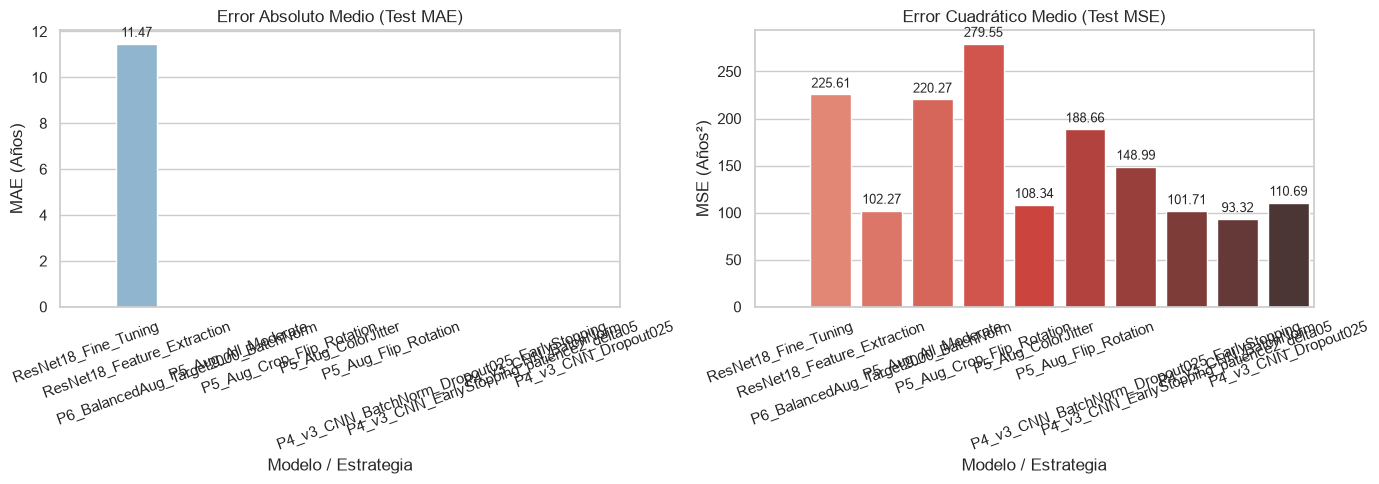

In [1]:
# ==============================================================================
# BLOQUE 3: COMPARATIVA Y VISUALIZACIÓN DE RESULTADOS (INDEPENDIENTE)
# ==============================================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

# 1. Configuración de conexión a MLflow (Mismos valores exactos)
TRACKING_URI = "sqlite:///mlruns/mlflow.db"
EXPERIMENT_NAME = "UTKFace_Age_Regression_Part4_Regularization_v3"
CSV_FILEPATH = "results.csv"  # Ruta opcional de CSV con métricas adicionales/previas

mlflow.set_tracking_uri(TRACKING_URI)

print(f"🔍 Consultando experimentos desde MLflow Database: {TRACKING_URI}...")

# 2. Consultar runs de MLflow para el experimento especificado
try:
    runs_df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
    print(f"✅ Se encontraron {len(runs_df)} ejecuciones en MLflow.")
except Exception as e:
    print(f"⚠️ No se pudo consultar MLflow directamente: {e}")
    runs_df = pd.DataFrame()

# 3. Procesar datos de MLflow
df_mlflow_metrics = pd.DataFrame()

if not runs_df.empty:
    # Identificar columnas de métricas de interés
    run_name_col = 'tags.mlflow.runName' if 'tags.mlflow.runName' in runs_df.columns else 'run_id'
    mae_col = 'metrics.test_mae' if 'metrics.test_mae' in runs_df.columns else None
    mse_col = 'metrics.test_loss' if 'metrics.test_loss' in runs_df.columns else None

    selected_cols = [col for col in [run_name_col, mae_col, mse_col] if col is not None]
    
    df_mlflow_metrics = runs_df[selected_cols].copy()
    
    # Renombrar columnas para estandarizar
    rename_dict = {}
    if run_name_col: rename_dict[run_name_col] = 'Modelo / Estrategia'
    if mae_col: rename_dict[mae_col] = 'Test MAE (Años)'
    if mse_col: rename_dict[mse_col] = 'Test MSE (Años²)'
    
    df_mlflow_metrics.rename(columns=rename_dict, inplace=True)

# 4. Lectura complementaria de archivo CSV (si existe en disco)
if os.path.exists(CSV_FILEPATH):
    print(f"📂 Archivo CSV detectado en '{CSV_FILEPATH}'. Combinando resultados...")
    try:
        df_csv = pd.read_csv(CSV_FILEPATH)
        df_combined = pd.concat([df_mlflow_metrics, df_csv], ignore_index=True)
    except Exception as e:
        print(f"⚠️ Error al leer el CSV: {e}")
        df_combined = df_mlflow_metrics
else:
    df_combined = df_mlflow_metrics

# 5. Limpieza y eliminación de duplicados por nombre de modelo
if not df_combined.empty:
    df_combined = df_combined.dropna(subset=['Modelo / Estrategia']).drop_duplicates(
        subset=['Modelo / Estrategia'], keep='last'
    )
    
    # 6. Imprimir Tabla Comparativa Resumen
    print("\n" + "="*65)
    print(f"📊 TABLA COMPARATIVA DE RESULTADOS: {EXPERIMENT_NAME}")
    print("="*65)
    print(df_combined.to_string(index=False))
    print("="*65 + "\n")

    # 7. Generar Gráficos de Barras Comparativos
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Test MAE
    if 'Test MAE (Años)' in df_combined.columns and not df_combined['Test MAE (Años)'].isna().all():
        sns.barplot(
            data=df_combined, 
            x="Modelo / Estrategia", 
            y="Test MAE (Años)", 
            ax=axes[0], 
            palette="Blues_d"
        )
        axes[0].set_title("Error Absoluto Medio (Test MAE)")
        axes[0].set_ylabel("MAE (Años)")
        axes[0].tick_params(axis='x', rotation=20)

        for p in axes[0].patches:
            height = p.get_height()
            if not pd.isna(height) and height > 0:
                axes[0].annotate(f"{height:.2f}", 
                                (p.get_x() + p.get_width() / 2., height), 
                                ha='center', va='bottom', fontsize=9, xytext=(0, 3), 
                                textcoords='offset points')

    # Gráfico 2: Test MSE
    if 'Test MSE (Años²)' in df_combined.columns and not df_combined['Test MSE (Años²)'].isna().all():
        sns.barplot(
            data=df_combined, 
            x="Modelo / Estrategia", 
            y="Test MSE (Años²)", 
            ax=axes[1], 
            palette="Reds_d"
        )
        axes[1].set_title("Error Cuadrático Medio (Test MSE)")
        axes[1].set_ylabel("MSE (Años²)")
        axes[1].tick_params(axis='x', rotation=20)

        for p in axes[1].patches:
            height = p.get_height()
            if not pd.isna(height) and height > 0:
                axes[1].annotate(f"{height:.2f}", 
                                (p.get_x() + p.get_width() / 2., height), 
                                ha='center', va='bottom', fontsize=9, xytext=(0, 3), 
                                textcoords='offset points')

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ No se encontraron métricas o ejecuciones para graficar.")